# Aula 05 — Otimização de hiperparâmetros no Google Colab

**Avanços em IA — EELT7025, PPGEE/UFPR**

**Adriely Teixeira de Paula · Betina Zynger Capaverde · Emilio Gaudeda Junior**

Concrete Compressive Strength (UCI 165) · GradientBoostingRegressor · resistência em MPa.

Escolha o modo abaixo e use **Ambiente de execução → Executar tudo**. Não é necessário enviar arquivos. O bootstrap baixa os materiais do GitHub e registra o commit efetivamente recebido. Use runtime **CPU**; este estudo não usa GPU.

- **analise_arquivada** (padrão): verifica os dados/resultados publicados e recalcula tabelas, análises e figuras, sem repetir HPO.
- **experimento_completo**: executa todos os 15 métodos/variantes, controles Dummy/Ridge, Optuna com 50% do treino, robustez dos vencedores com cinco seeds, verificação e gráficos, em pasta nova.

O ambiente científico é um **venv Python 3.12 isolado**. As dependências do kernel Colab permanecem intactas. Uma versão diferente de Python pode exigir o download de Python 3.12 via uv. A primeira instalação demora alguns minutos; o tempo dos experimentos varia com os recursos disponíveis. Colab pode encerrar sessões: não há técnica para contornar limites, e logs/resultados parciais ficam preservados enquanto o runtime existir.

In [1]:
# @title Configuração
MODO = "analise_arquivada" # @param ["analise_arquivada", "experimento_completo"]
DADOS = "snapshot_publicado" # @param ["snapshot_publicado", "nova_consulta_uci"]
MAX_CPU_FOLDS = 5 # @param {type:"integer"}
MAX_HORAS = 6 # @param {type:"number"}
REPO_URL = 'https://github.com/juniortlr/avancos-ia-masters.git'
REPO_REF = '02d110722f2aee6f9d684faa748afcd932821477' # @param {type:"string"}
REPO_SLUG = 'juniortlr/avancos-ia-masters'
REQUIREMENTS_TEXT = '# Python 3.12; direct scientific dependencies from the original experiment.\n# The notebook installs these into its own venv, never into the Colab kernel.\n# [analysis] is sufficient to verify archived CSV/NPZ evidence and redraw figures.\n# [analysis]\nnumpy==2.5.3\npandas==3.0.6\nscipy==1.18.1\nscikit-learn==1.9.1\nmatplotlib==3.11.2\njoblib==1.6.0\nthreadpoolctl==3.7.0\n# [experiments] adds every optimizer required by the assignment.\n# [experiments]\nucimlrepo==0.0.7\nscikit-optimize==0.10.2\nbayesian-optimization==3.3.0\noptuna==5.0.0\nhyperopt==0.3.0\nray[tune]==2.58.0\ndeap==1.4.4\n# Hyperopt compatibility: retain the setuptools version used by the study.\nsetuptools==80.10.2\n'
if not 1 <= int(MAX_CPU_FOLDS) <= 5: raise ValueError('MAX_CPU_FOLDS deve estar entre 1 e 5.')
if not 0 < float(MAX_HORAS) <= 12: raise ValueError('MAX_HORAS deve estar em (0,12].')


## 1. Baixar materiais e preparar ambiente isolado

O snapshot publicado conserva os dados e o split usados no relatório. No modo integral, a opção `nova_consulta_uci` refaz `fetch_ucirepo(id=165)`; uma mudança futura da fonte pode alterar os resultados. O script limita o paralelismo à CPU disponível e usa no máximo um trial Ray por vez. Os 40 trials Ray e seus estágios ASHA permanecem completos; o teto de parede interrompe com erro explícito, sem fingir conclusão.

In [2]:

from pathlib import Path
from datetime import datetime, timezone
import csv, hashlib, html, importlib.util, json, math, os, platform, re
import shutil, signal, subprocess, sys, tempfile, time, uuid
from IPython.display import display, Markdown, Image, HTML, FileLink

if MODO not in ('analise_arquivada', 'experimento_completo'):
    raise ValueError('Escolha um dos dois modos documentados.')
BASE = (Path('/content') if Path('/content').is_dir() else Path.cwd()) / 'aula05_colab'
BASE.mkdir(parents=True, exist_ok=True)
RUN_ID = datetime.now(timezone.utc).strftime('%Y%m%dT%H%M%SZ') + '-' + uuid.uuid4().hex[:8]
RUN_DIR = BASE / 'runs' / (RUN_ID + '-' + MODO)
RUN_DIR.mkdir(parents=True, exist_ok=False)
LOG_DIR = RUN_DIR / 'logs'
LOG_DIR.mkdir()
# Ray creates AF_UNIX sockets below its temp directory. Keep this path short.
RAY_TEMP = Path(tempfile.gettempdir()) / ('a05r-' + uuid.uuid4().hex[:8])
RAY_TEMP.mkdir(exist_ok=False)
ENV = os.environ.copy()
for inherited in ['PYTHONPATH','PYTHONHOME']:
    ENV.pop(inherited,None)
ENV.update({'OMP_NUM_THREADS':'1','OPENBLAS_NUM_THREADS':'1','MKL_NUM_THREADS':'1',
            'NUMEXPR_NUM_THREADS':'1','PYTHONNOUSERSITE':'1','PYTHONUNBUFFERED':'1',
            'MPLBACKEND':'Agg','PIP_PROGRESS_BAR':'off',
            'RAY_USAGE_STATS_ENABLED':'0','MPLCONFIGDIR':str(RUN_DIR/'.matplotlib'),
            'RAY_TMPDIR':str(RAY_TEMP)})
EVENTS = []

def sha256(path):
    h=hashlib.sha256()
    with Path(path).open('rb') as f:
        for chunk in iter(lambda:f.read(1024*1024),b''): h.update(chunk)
    return h.hexdigest()

def write_json(path, data):
    Path(path).write_text(json.dumps(data,ensure_ascii=False,indent=2,allow_nan=False),encoding='utf-8')

def run_command(args, name, cwd=None, timeout=3600, env=None):
    """Bound a process group; retain its exact command, log and exit status."""
    args=[str(a) for a in args]
    log=LOG_DIR/(name+'.log')
    started=time.monotonic()
    record={'stage':name,'command':args,'started_utc':datetime.now(timezone.utc).isoformat(),
            'timeout_seconds':timeout,'log':str(log.relative_to(RUN_DIR)),'status':'running'}
    EVENTS.append(record);write_json(RUN_DIR/'execution-events.json',EVENTS)
    print(f'[{name}] iniciado. Log: {log.name}',flush=True)
    pos=0;shown=time.monotonic()
    with log.open('wb') as target:
        proc=subprocess.Popen(args,cwd=cwd,env=env or ENV,stdout=target,stderr=subprocess.STDOUT,
                              start_new_session=(os.name=='posix'))
        try:
            while proc.poll() is None:
                elapsed=time.monotonic()-started
                if elapsed>timeout:
                    if os.name=='posix': os.killpg(proc.pid,signal.SIGTERM)
                    else: proc.terminate()
                    try:proc.wait(timeout=10)
                    except subprocess.TimeoutExpired:
                        if os.name=='posix':os.killpg(proc.pid,signal.SIGKILL)
                        else:proc.kill()
                    record['status']='timeout'
                    raise TimeoutError(f'{name} ultrapassou {timeout:.0f} s; evidências parciais preservadas em {RUN_DIR}')
                if time.monotonic()-shown>=5:
                    data=log.read_bytes()
                    if len(data)>pos:print(data[pos:].decode('utf-8',errors='replace'),end='',flush=True);pos=len(data)
                    else:print(f'[{name}] {elapsed:.0f} s...',flush=True)
                    shown=time.monotonic()
                time.sleep(.5)
            target.flush()
            data=log.read_bytes()
            if len(data)>pos:print(data[pos:].decode('utf-8',errors='replace'),end='',flush=True)
            record['returncode']=proc.returncode
            record['status']='complete' if proc.returncode==0 else 'failed'
            if proc.returncode:
                raise RuntimeError(f'{name} falhou com exit {proc.returncode}; consulte {log}')
        finally:
            if proc.poll() is None:
                if os.name=='posix':os.killpg(proc.pid,signal.SIGTERM)
                else:proc.terminate()
            record['elapsed_seconds']=time.monotonic()-started
            if record['status']=='running':record['status']='interrupted'
            write_json(RUN_DIR/'execution-events.json',EVENTS)
    return log

def capture(args,env=None):
    return subprocess.check_output([str(a) for a in args],env=env or ENV,text=True).strip()

SOURCE=BASE/'sources'/RUN_ID
SOURCE.parent.mkdir(exist_ok=True)
run_command(['git','init',SOURCE],'git-init',timeout=60)
run_command(['git','-C',SOURCE,'remote','add','origin',REPO_URL],'git-origin',timeout=60)
run_command(['git','-C',SOURCE,'fetch','--depth','1','origin',REPO_REF],'git-fetch',timeout=600)
run_command(['git','-C',SOURCE,'checkout','--detach','FETCH_HEAD'],'git-checkout',timeout=60)
RESOLVED_COMMIT=capture(['git','-C',SOURCE,'rev-parse','HEAD'])
if re.fullmatch(r'[0-9a-fA-F]{40}',REPO_REF) and RESOLVED_COMMIT.lower()!=REPO_REF.lower():
    raise RuntimeError('O commit recebido não corresponde ao SHA solicitado.')
ARCHIVE=SOURCE/'tarefa5'
for required in ['experiment.py','plot_results.py','data/uci165_raw.csv','data/data-contract.json','results/metrics.csv']:
    if not (ARCHIVE/required).is_file():raise FileNotFoundError(f'Commit sem material obrigatório: tarefa5/{required}')
print('Commit efetivamente obtido:',RESOLVED_COMMIT)

# Available CPU means affinity plus cgroup quota, not just os.cpu_count().
limits=[os.cpu_count() or 1]
if hasattr(os,'sched_getaffinity'):limits.append(len(os.sched_getaffinity(0)))
try:
    q,period=Path('/sys/fs/cgroup/cpu.max').read_text().split()
    if q!='max':limits.append(max(1,math.floor(int(q)/int(period))))
except (OSError,ValueError):pass
AVAILABLE_CPUS=max(1,min(limits))
CV_JOBS=max(1,min(5,AVAILABLE_CPUS,int(MAX_CPU_FOLDS)))
free_gib=shutil.disk_usage(BASE).free/(1024**3)
if free_gib<1.5:raise RuntimeError(f'Espaço livre insuficiente para ambiente isolado: {free_gib:.2f} GiB.')
print(f'CPU disponível: {AVAILABLE_CPUS}; folds paralelos: {CV_JOBS}; livre: {free_gib:.1f} GiB. GPU não utilizada.')

for name in ['experiment.py','plot_results.py','study-protocol.md','search-budget.json']:
    if (ARCHIVE/name).exists():shutil.copy2(ARCHIVE/name,RUN_DIR/name)

if MODO=='analise_arquivada':
    shutil.copytree(ARCHIVE/'data',RUN_DIR/'data')
    # Evidence required by verify/plots; model pickles and Ray runtime internals are not loaded.
    shutil.copytree(ARCHIVE/'results',RUN_DIR/'results',
                    ignore=shutil.ignore_patterns('model.joblib','ray-storage','*_superseded_*','__pycache__'))
else:
    (RUN_DIR/'data').mkdir()
    if DADOS=='snapshot_publicado':
        for name in ['uci165_raw.csv','uci_metadata.json']:
            if (ARCHIVE/'data'/name).exists():shutil.copy2(ARCHIVE/'data'/name,RUN_DIR/'data'/name)
    elif DADOS!='nova_consulta_uci':raise ValueError('Fonte dos dados desconhecida.')

# Never rewrite original files. Every installation and derived output is under BASE.
(RUN_DIR/'requirements-colab.txt').write_text(REQUIREMENTS_TEXT,encoding='utf-8')
selected=[];section='analysis'
for line in REQUIREMENTS_TEXT.splitlines():
    if line.strip()=='# [experiments]':section='experiments'
    if line.strip() and not line.lstrip().startswith('#'):
        if section=='analysis' or MODO=='experimento_completo':selected.append(line.strip())
(RUN_DIR/'requirements-selected.txt').write_text('\n'.join(selected)+'\n',encoding='utf-8')

VENV=BASE/'environments'/('py312-'+hashlib.sha256('\n'.join(selected).encode()).hexdigest()[:16])
VENV_PY=VENV/('Scripts/python.exe' if os.name=='nt' else 'bin/python')
VENV.parent.mkdir(exist_ok=True)
venv_ready=False
if VENV_PY.exists():
    try:
        venv_ready=(capture([VENV_PY,'-c','import sys,pip;print("%s.%s"%sys.version_info[:2])'])=='3.12')
    except (OSError,subprocess.CalledProcessError):pass
if not venv_ready:
    candidates=[sys.executable,shutil.which('python3.12')]
    python312=None
    for candidate in candidates:
        if candidate:
            try:
                if capture([candidate,'-c','import sys;print("%s.%s"%sys.version_info[:2])'])=='3.12':python312=candidate;break
            except (OSError,subprocess.CalledProcessError):pass
    if python312:
        try:
            run_command([python312,'-m','venv',VENV],'create-venv',timeout=300)
            venv_ready=True
        except RuntimeError:
            print('venv/ensurepip indisponível neste Python; recuperação isolada via uv. Consulte create-venv.log.')
    if not venv_ready:
        # uv is a bootstrap utility installed in an isolated target, not in the kernel.
        tools_dir=BASE/'bootstrap-tools'
        run_command([sys.executable,'-m','pip','install','--no-cache-dir','--target',tools_dir,'uv'],
                    'install-uv-bootstrap',timeout=600)
        uv_env=ENV.copy();uv_env.update({'PYTHONPATH':str(tools_dir),
            'UV_CACHE_DIR':str(BASE/'uv-cache'),'UV_PYTHON_INSTALL_DIR':str(BASE/'python'),
            'UV_PYTHON_BIN_DIR':str(BASE/'python-bin')})
        run_command([sys.executable,'-m','uv','venv','--python',python312 or '3.12','--seed','--allow-existing',VENV],
                    'create-python312-venv',timeout=900,env=uv_env)
        (RUN_DIR/'uv-version.txt').write_text(capture([sys.executable,'-m','uv','--version'],env=uv_env),encoding='utf-8')
run_command([VENV_PY,'-m','pip','install','--no-cache-dir','-r',RUN_DIR/'requirements-selected.txt'],
            'install-scientific-dependencies',timeout=1800)
run_command([VENV_PY,'-m','pip','check'],'pip-check',timeout=120)
(RUN_DIR/'environment-freeze.txt').write_text(capture([VENV_PY,'-m','pip','freeze']),encoding='utf-8')
runtime=json.loads(capture([VENV_PY,'-c','import sys,platform,json;print(json.dumps({"python":sys.version,"platform":platform.platform()}))']))
MANIFEST={'mode':MODO,'repo_url':REPO_URL,'requested_ref':REPO_REF,'resolved_commit':RESOLVED_COMMIT,
    'created_utc':datetime.now(timezone.utc).isoformat(),'kernel_python':sys.version,
    'experiment_runtime':runtime,'cv_jobs_requested':CV_JOBS,'available_cpus':AVAILABLE_CPUS,
    'data_origin':DADOS if MODO=='experimento_completo' else 'archived_snapshot',
    'time_limit_hours':MAX_HORAS,'ray_trials':40,'ray_max_concurrent_trials':1,
    'ray_temp_dir':str(RAY_TEMP),
    'ray_resources':'at most CV_JOBS local CPUs; no GPU or remote cluster',
    'parallelism_note':'The archived engine contains a static original-run parallelism description mentioning 5 workers. For newly computed results, use each result cv_jobs and this manifest as the actual count; Ray receives the same count.',
    'code_sha256':{n:sha256(RUN_DIR/n) for n in ['experiment.py','plot_results.py']},
    'original_archive_untouched':True,'validation_scope':'This run logs its own execution; hosted Colab testing is not implied by local Linux tests.'}
write_json(RUN_DIR/'colab-run-manifest.json',MANIFEST)
print('Ambiente científico isolado:',VENV_PY)
print('Artefatos desta execução:',RUN_DIR)


[git-init] iniciado. Log: git-init.log


hint: Using 'master' as the name for the initial branch. This default branch name
hint: will change to "main" in Git 3.0. To configure the initial branch name
hint: to use in all of your new repositories, which will suppress this warning,
hint: call:
hint:
hint: 	git config --global init.defaultBranch <name>
hint:
hint: Names commonly chosen instead of 'master' are 'main', 'trunk' and
hint: 'development'. The just-created branch can be renamed via this command:
hint:
hint: 	git branch -m <name>
hint:
hint: Disable this message with "git config set advice.defaultBranchName false"
Initialized empty Git repository in /root/codex-aula05-validation/work/aula05_colab/sources/20261001T002128Z-d889e05b/.git/


[git-origin] iniciado. Log: git-origin.log


[git-fetch] iniciado. Log: git-fetch.log


[git-fetch] 5 s...


...

HEAD is now at 02d1107 Archive Aula 05 experiments, notebooks, reports and course references


Commit efetivamente obtido: 02d110722f2aee6f9d684faa748afcd932821477
CPU disponível: 16; folds paralelos: 5; livre: 952.7 GiB. GPU não utilizada.
[install-scientific-dependencies] iniciado. Log: install-scientific-dependencies.log


[pip-check] iniciado. Log: pip-check.log


No broken requirements found.


Ambiente científico isolado: /root/codex-aula05-validation/work/aula05_colab/environments/py312-15cc88d67aa5d412/bin/python
Artefatos desta execução: /root/codex-aula05-validation/work/aula05_colab/runs/20261001T002128Z-d889e05b-analise_arquivada


## 2. Executar o modo escolhido

No modo integral, todas as buscas começam sem resultados prévios. Apenas a seed 42 recém-calculada é reutilizada na robustez. As tabelas do arquivo original nunca são sobrescritas. A ordem inclui explicitamente `supplement`, que estava ausente do atalho de reprodução do notebook local original.

In [3]:

deadline=time.monotonic()+float(MAX_HORAS)*3600
def execute_engine(arguments,label):
    remaining=deadline-time.monotonic()
    if remaining<=0:raise TimeoutError('Orçamento de parede esgotado; resultados parciais estão preservados.')
    run_command([VENV_PY,RUN_DIR/'experiment.py',*arguments],label,cwd=RUN_DIR,timeout=remaining)

if MODO=='experimento_completo':
    # All required methods and all supplemental procedures; no archived score reuse.
    execute_engine(['prepare'],'01-prepare')
    execute_engine(['supplement','--jobs',str(CV_JOBS)],'02-supplement')
    execute_engine(['run','--method','all','--jobs',str(CV_JOBS)],'03-all-methods')
    execute_engine(['sample','--jobs',str(CV_JOBS)],'04-optuna-half-training')
    execute_engine(['robustness','--jobs',str(CV_JOBS),'--resume'],'05-robustness')
    # --resume above reuses only seed42 just generated within this new run.
execute_engine(['verify'],'06-verify')
run_command([VENV_PY,RUN_DIR/'plot_results.py'],'07-reconstruct-analysis',cwd=RUN_DIR,
            timeout=max(1,deadline-time.monotonic()))
analysis=json.loads((RUN_DIR/'results'/'analysis.json').read_text(encoding='utf-8'))
if len(analysis['metrics'])!=15:raise RuntimeError('A tabela precisa conter os 12 métodos e três variantes.')
if set(analysis.get('robustness_by_method',{})) != {analysis['best_cv_method'],analysis['best_test_method']}:
    raise RuntimeError('Faltou uma das séries de robustez dos vencedores.')
for method,stats in analysis['robustness_by_method'].items():
    if sorted(int(row['seed']) for row in stats['rows']) != [0,7,21,42,99]:
        raise RuntimeError(f'Robustez incompleta para {method}.')
if MODO=='experimento_completo':
    # The original plotting source proposes Optuna based on the original study.
    # Do not silently turn that historical judgement into a new recommendation.
    analysis['archived_recommendation_not_transferred']=analysis.pop('recommendation',None)
    analysis['narrative'].pop('recommendation',None)
    analysis['recommendation']={'status':'requires_interpretation_of_new_run',
        'formal_cv_selection':analysis['best_cv_method'],
        'descriptive_test_winner':analysis['best_test_method'],
        'reason':'The original Optuna operational judgement is not automatically transferred to a new runtime.'}
    write_json(RUN_DIR/'results'/'analysis.json',analysis)
MANIFEST['status']='complete'
MANIFEST['figure_count']=len(list((RUN_DIR/'figures').glob('*.png')))
MANIFEST['completed_utc']=datetime.now(timezone.utc).isoformat()
write_json(RUN_DIR/'colab-run-manifest.json',MANIFEST)
print(f'Concluído: {len(analysis["metrics"])} métodos/variantes, {MANIFEST["figure_count"]} figuras.')
print('Os tempos da análise arquivada permanecem os da execução original; não são um benchmark deste Colab.'
      if MODO=='analise_arquivada' else 'Tempos novos são específicos deste runtime e de CV_JOBS, sem comparação direta com os tempos Windows arquivados.')


[06-verify] iniciado. Log: 06-verify.log


{"verified": ["baseline", "grid", "random", "gp_manual", "bayessearch", "bayesopt", "optuna", "hyperopt", "ray", "ga", "de_best1bin", "de_rand1bin", "pso_w07", "pso_w04", "pso_w09"]}


[07-reconstruct-analysis] iniciado. Log: 07-reconstruct-analysis.log


[07-reconstruct-analysis] 5 s...


[07-reconstruct-analysis] 10 s...


{"metrics": 15, "figures": 28, "best_cv_method": "pso_w09", "best_test_method": "de_rand1bin", "analysis": "/root/codex-aula05-validation/work/aula05_colab/runs/20261001T002128Z-d889e05b-analise_arquivada/results/analysis.json"}


Concluído: 15 métodos/variantes, 28 figuras.
Os tempos da análise arquivada permanecem os da execução original; não são um benchmark deste Colab.


## 3. Resultados e respostas aos exercícios

As células seguintes usam somente os artefatos da pasta desta execução. O kernel apenas apresenta JSON, CSV e PNG; todos os cálculos científicos ocorreram no venv. A seleção formal usa CV; o menor RMSE de teste é um vencedor descritivo exigido pelo enunciado, com o viés de seleção explicitado.

In [4]:

def table_rows(rows,columns=None,quality=False):
    rows=list(rows)
    if not rows:return display(Markdown('Sem linhas disponíveis.'))
    columns=columns or list(rows[0])
    out=['<table style="border-collapse:collapse;font-size:13px"><tr>']
    out.extend('<th style="padding:6px;border:1px solid #aaa">'+html.escape(str(c))+'</th>' for c in columns)
    out.append('</tr>')
    for row in rows:
        out.append('<tr>')
        for c in columns:
            value=row.get(c,'');background='white'
            if quality and c in ('cv_rmse','test_rmse','test_mae','test_r2','total_seconds'):
                values=[float(r[c]) for r in rows]
                best=max(values) if c=='test_r2' else min(values)
                if math.isclose(float(value),best,rel_tol=1e-10,abs_tol=1e-12):
                    background='#fff2b0' if c=='total_seconds' else '#bbdfb5'
            if isinstance(value,float):value=f'{value:.6g}'
            out.append(f'<td style="padding:6px;border:1px solid #ccc;background:{background}">'+html.escape(str(value))+'</td>')
        out.append('</tr>')
    display(HTML(''.join(out)+'</table>'))

def csv_table(relative,columns=None):
    with (RUN_DIR/relative).open(encoding='utf-8-sig',newline='') as f:table_rows(csv.DictReader(f),columns)

def figure(stem):display(Image(filename=str(RUN_DIR/'figures'/(stem+'.png'))))
def finding(key):display(Markdown(analysis['narrative'][key]))
def methods(names=None):
    rows=analysis['metrics']
    if names:rows=[r for r in rows if r['method'] in names]
    table_rows(rows,['method','cv_rmse','test_rmse','test_mae','test_r2','total_seconds','n_evaluations'],quality=True)

display(Markdown('**Modo:** '+MODO+' · **commit dos materiais:** `'+RESOLVED_COMMIT+'`.'))
display(Markdown('**Original preservado:** [notebook executado da entrega](https://github.com/'+REPO_SLUG+'/blob/'+RESOLVED_COMMIT+'/tarefa5/Aula05_Tarefa5_Resultados.ipynb).'))


**Modo:** analise_arquivada · **commit dos materiais:** `02d110722f2aee6f9d684faa748afcd932821477`.

**Original preservado:** [notebook executado da entrega](https://github.com/juniortlr/avancos-ia-masters/blob/02d110722f2aee6f9d684faa748afcd932821477/tarefa5/Aula05_Tarefa5_Resultados.ipynb).

### Exercício 1 — dados, baseline e buscas clássicas

Duplicatas exatas de X+y são removidas antes do split 80/20 com seed 42. Mediana e StandardScaler são ajustados dentro de cada fold do pipeline. O alvo mantém MPa. O CV usa cinco folds embaralhados com seed 42; a EDA usa somente o treino, enquanto a tabela de qualidade/describe caracteriza a fonte integral.

In [5]:
contract=json.loads((RUN_DIR/'data'/'data-contract.json').read_text(encoding='utf-8'))
display(HTML('<pre>'+html.escape(json.dumps(contract,ensure_ascii=False,indent=2))+'</pre>'))
csv_table('data/quality-summary.csv')
csv_table('data/describe_raw.csv')

column,dtype,missing_count,missing_fraction
Cement,float64,0,0.0
Blast Furnace Slag,float64,0,0.0
Fly Ash,float64,0,0.0
Water,float64,0,0.0
Superplasticizer,float64,0,0.0
Coarse Aggregate,float64,0,0.0
Fine Aggregate,float64,0,0.0
Age,int64,0,0.0
target_mpa,float64,0,0.0


,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,target_mpa
count,1030.0,1030.0,1030.0,1030.0,1030.0,1030.0,1030.0,1030.0,1030.0
mean,281.16786407766995,73.89582524271846,54.18834951456311,181.56728155339806,6.204660194174758,972.9189320388349,773.5804854368932,45.662135922330094,35.817961165048544
std,104.50636449481532,86.27934174810584,63.99700415268765,21.35421856503247,5.97384139248552,77.75395396672077,80.17598014240437,63.16991158103249,16.705741961912512
min,102.0,0.0,0.0,121.8,0.0,801.0,594.0,1.0,2.33
25%,192.375,0.0,0.0,164.9,0.0,932.0,730.95,7.0,23.71
50%,272.9,22.0,0.0,185.0,6.4,968.0,779.5,28.0,34.445
75%,350.0,142.95,118.3,192.0,10.2,1029.4,824.0,56.0,46.135000000000005
max,540.0,359.4,200.1,247.0,32.2,1145.0,992.6,365.0,82.6


In [6]:
finding('feature_overlap')

A auditoria encontrou 5 vetores distintos de oito features presentes em treino e teste, envolvendo 8 linhas de treino e 5 de teste. Os alvos diferem, portanto essas linhas não eram duplicatas exatas de X+y. Mantivemos o split predefinido; o resultado descreve generalização para observações reservadas, não desempenho garantido em misturas inéditas. Uma avaliação por grupos de composição/idade seria necessária para essa outra pergunta.

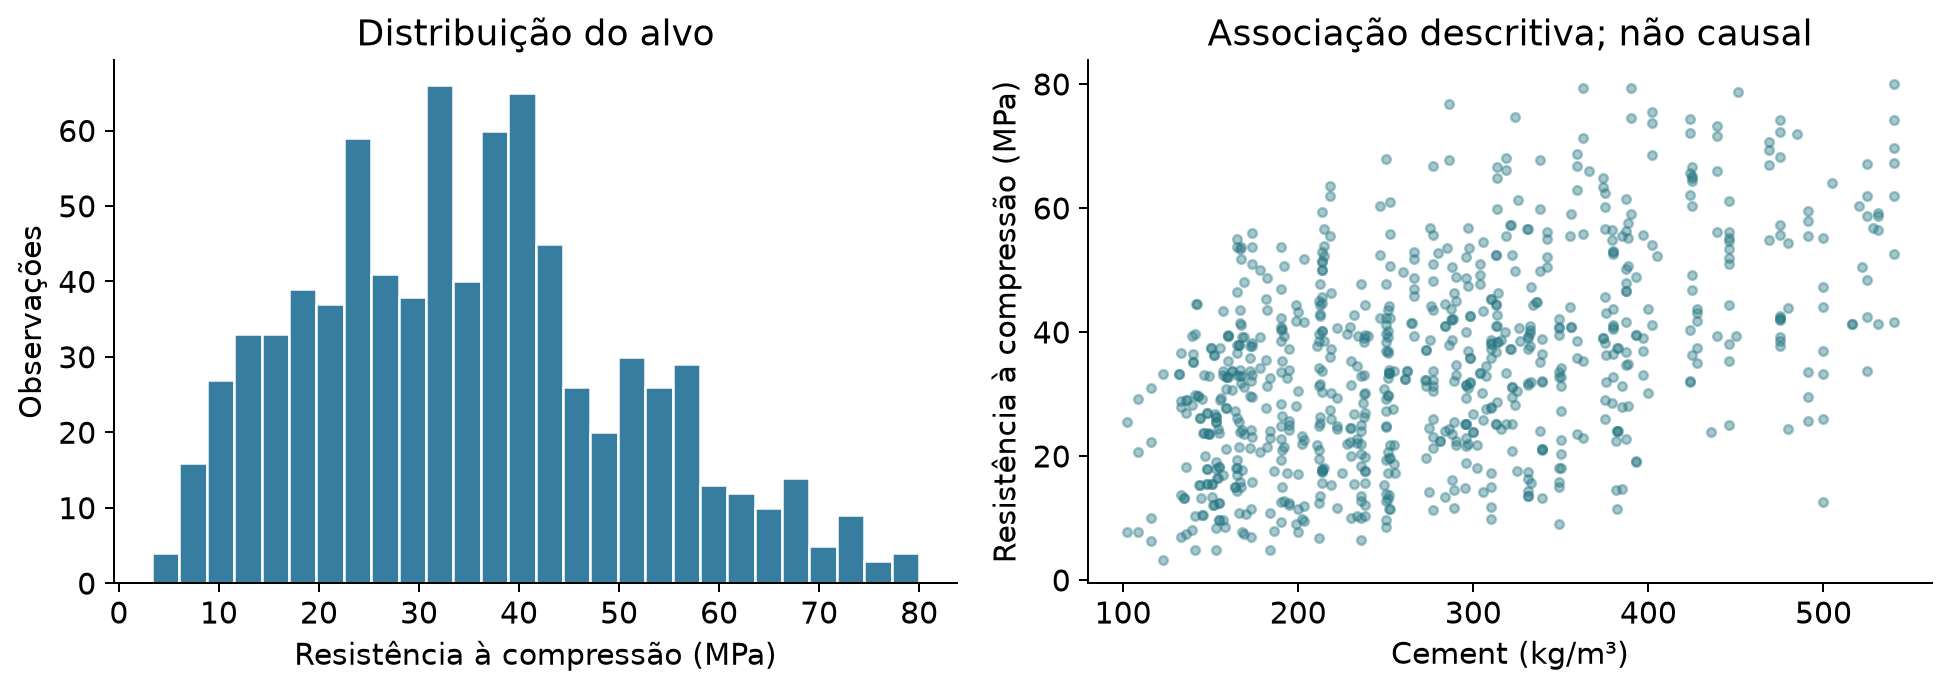

In [7]:
figure('01_eda_distributions')

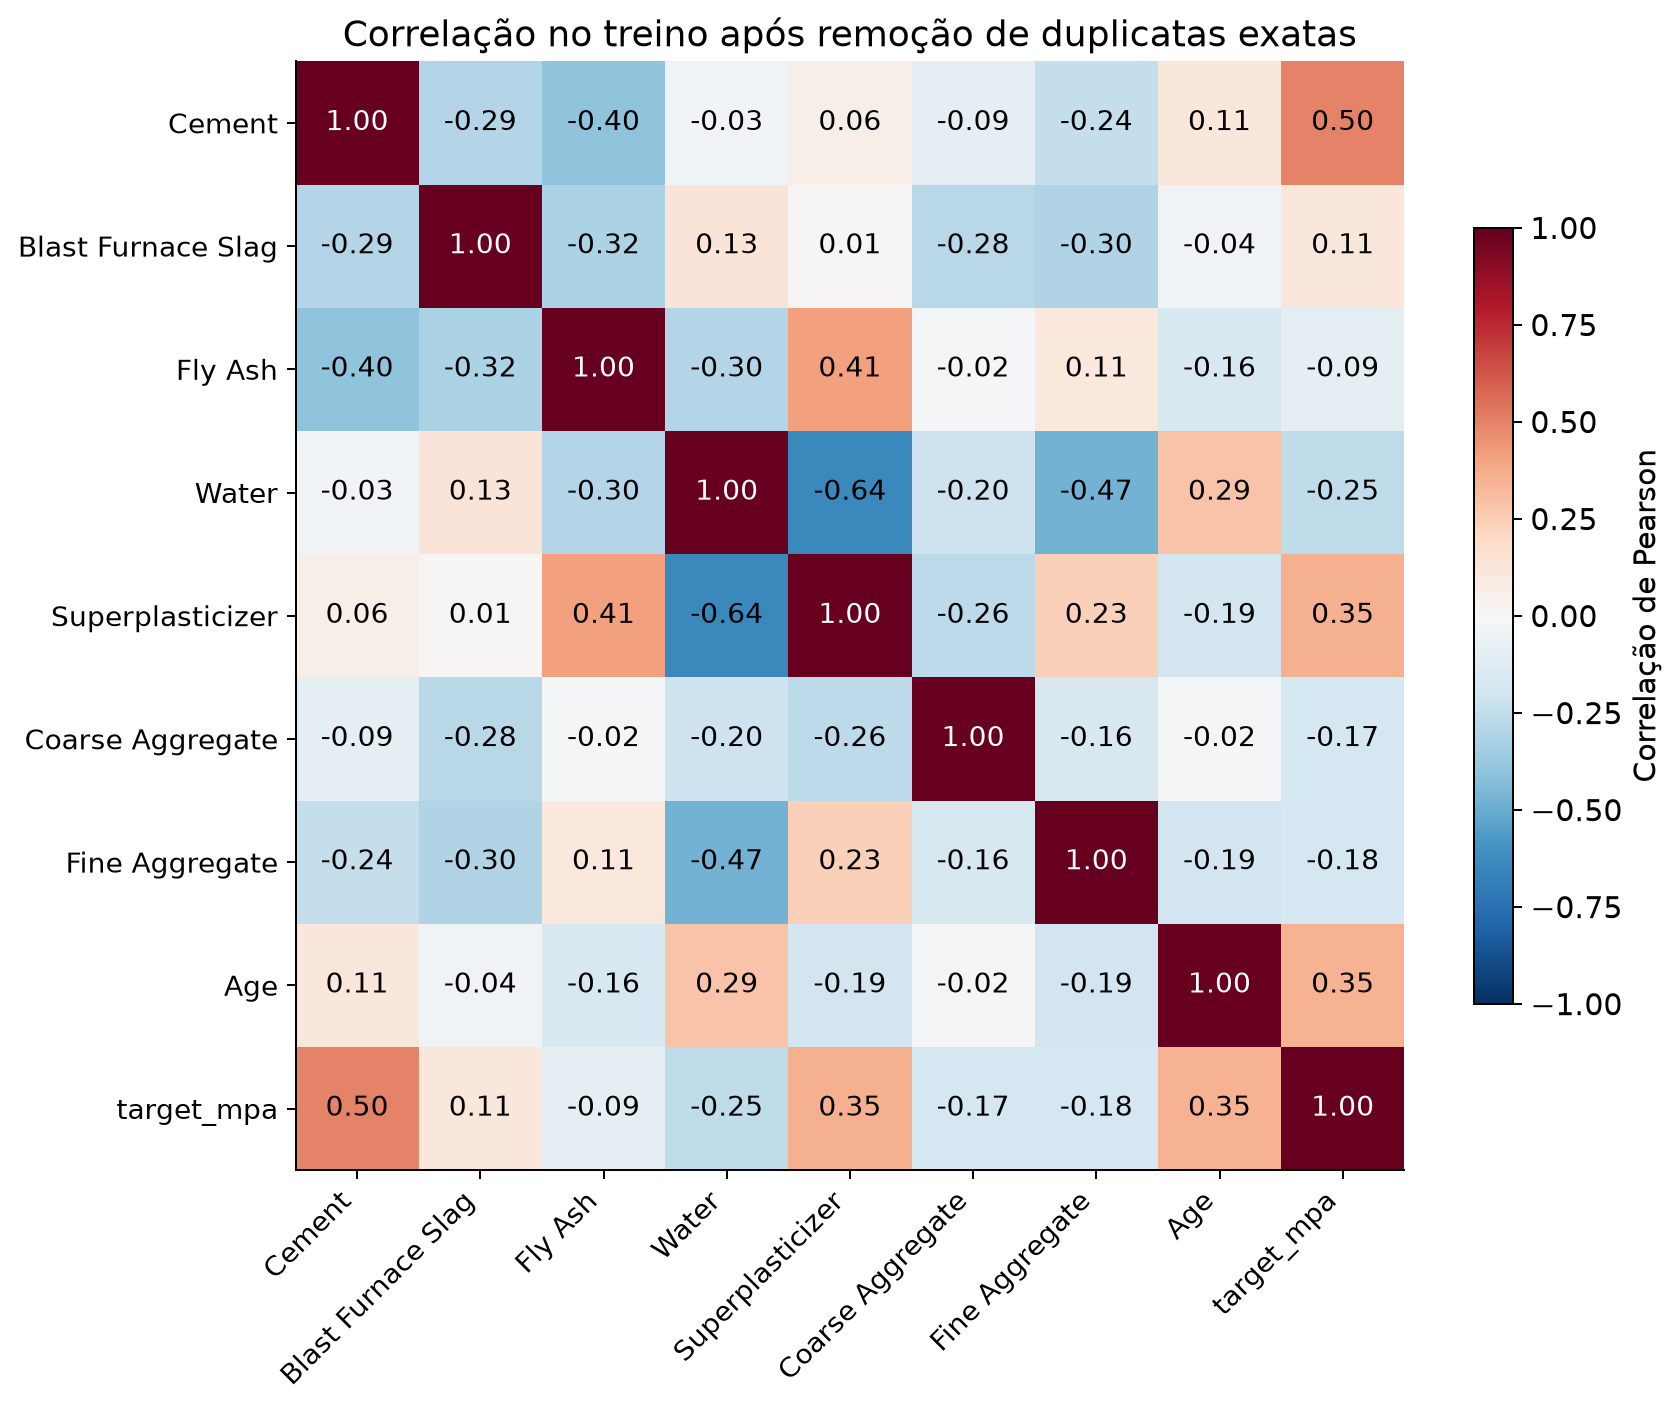

In [8]:
figure('02_eda_correlations')

**Itens 2–5.** O GBR baseline mantém os defaults sklearn, exceto a seed. Grid tem 36 pontos; Random avalia 30 da mesma grade. As curvas seguem a ordem registrada em `cv_results_`, sem prometer ordem cronológica de término de fits paralelos. No heatmap, n_estimators é fixado no melhor valor da grade. Correlações Spearman usam RMSE positivo (menor é melhor).

In [9]:
methods(['baseline','grid','random'])
csv_table('results/supplemental-baselines.csv')

method,cv_rmse,test_rmse,test_mae,test_r2,total_seconds,n_evaluations
baseline,5.29537,5.60385,4.1284,0.894735,0.349276,1
grid,4.73269,4.46302,3.14114,0.933232,4.13446,36
random,4.73269,4.46302,3.14114,0.933232,3.41239,30


method,cv_rmse,test_rmse,test_mae,test_r2,search_seconds,refit_seconds,total_seconds
dummy_mean,16.02834514648868,17.296409546308738,13.971914865968664,-0.0028187174165523743,0.1499291000654921,0.01336119999177754,0.16329030005726963
ridge_alpha1,10.201809281617049,11.19335339070423,8.897597667613853,0.5800177441313177,0.015683899982832372,0.005643100012093782,0.021326999994926155


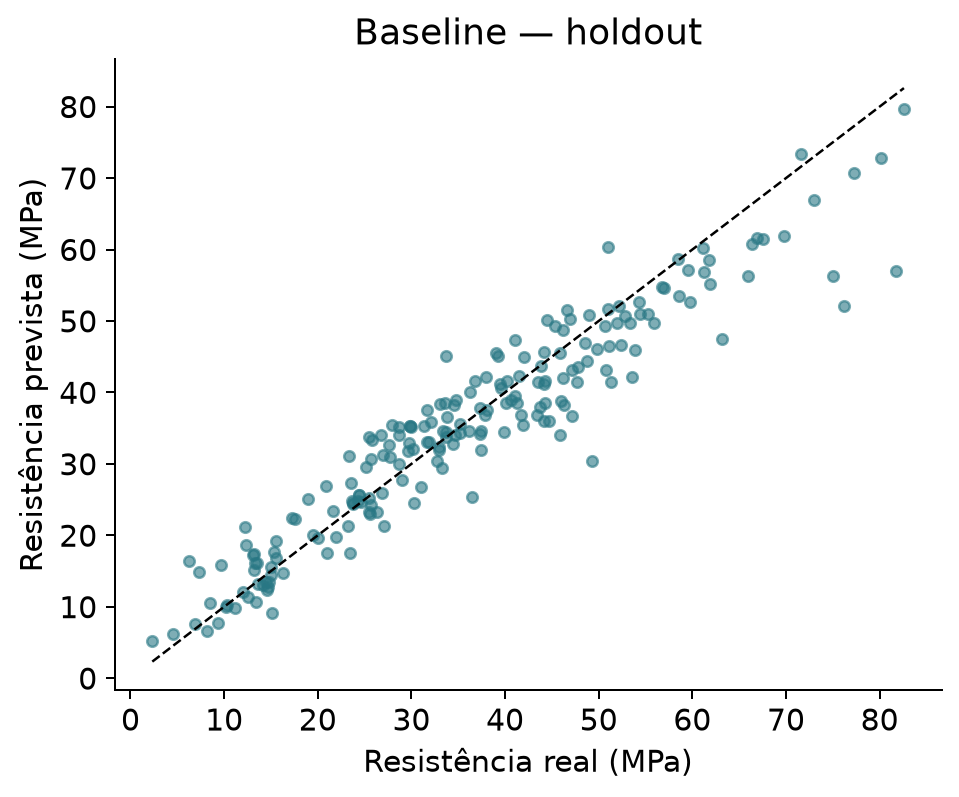

In [10]:
figure('03_baseline_predictions')

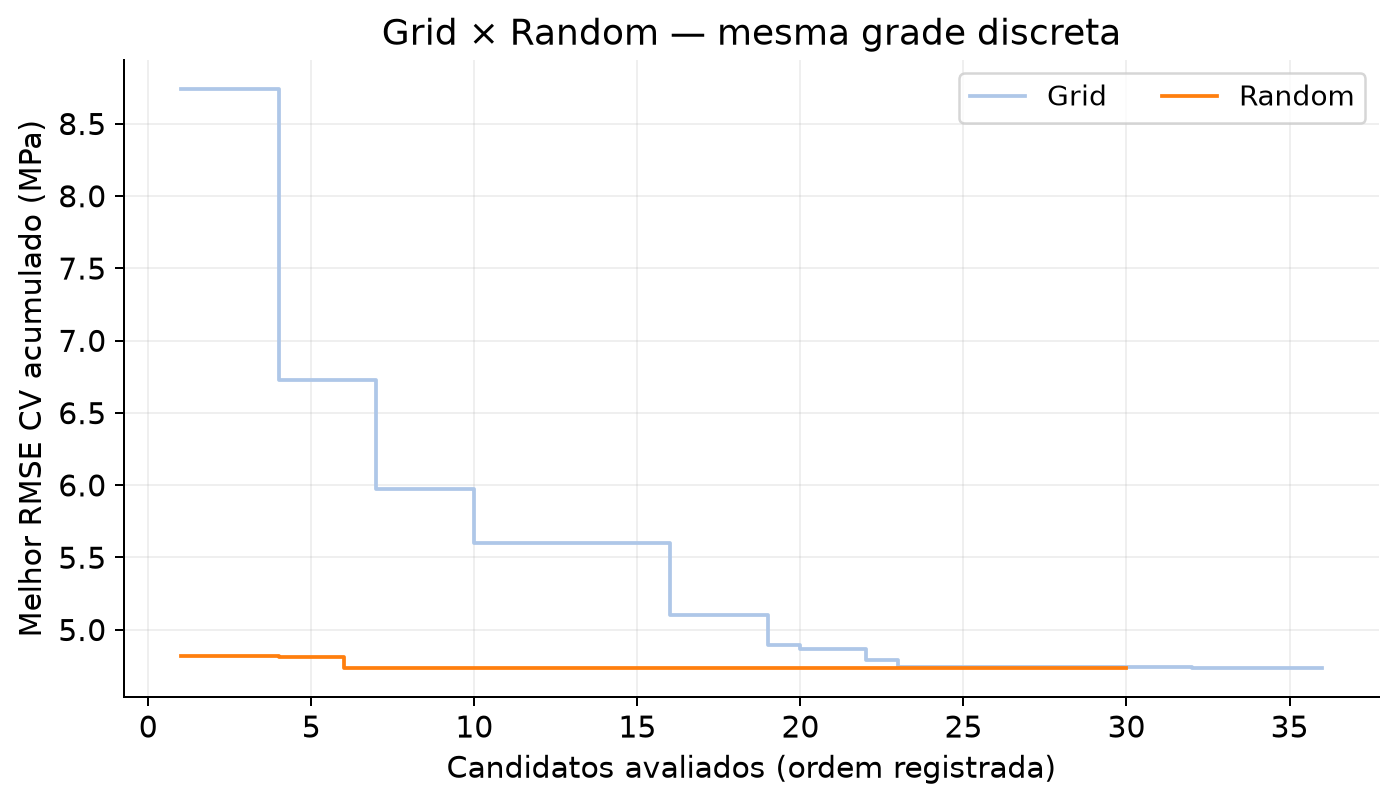

In [11]:
figure('04_grid_random_convergence')

In [12]:
finding('random_vs_grid')

Random igualou o ótimo CV da grade na avaliação 6. Ele não pode superá-lo estritamente, pois amostra um subconjunto dos mesmos 36 candidatos sob folds e seed idênticos.

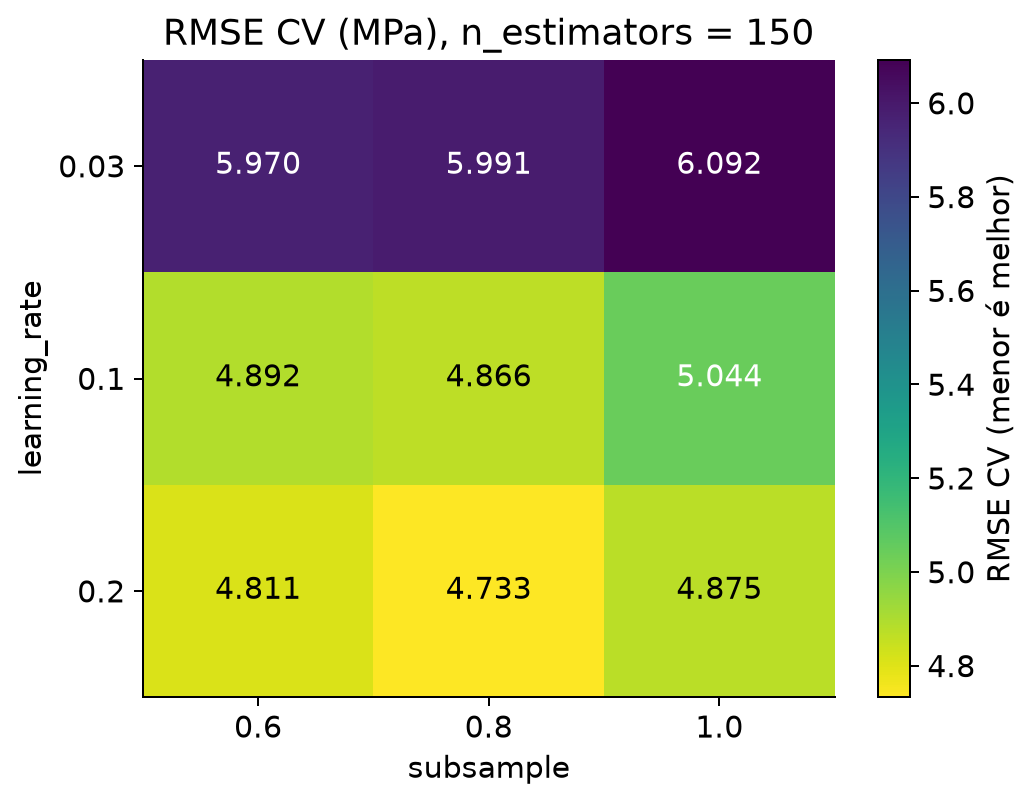

In [13]:
figure('05_grid_heatmap')

In [14]:
finding('heatmap')

No corte n_estimators=150, a mudança LR0,03→0,20 altera o RMSE em -1.159 MPa em subsample=0.6, -1.258 MPa em subsample=0.8, -1.217 MPa em subsample=1.0. Efeitos diferentes sugerem interação no conjunto discretizado; nove pontos não permitem demonstrar suavidade nem mapear todos os ótimos locais contínuos.

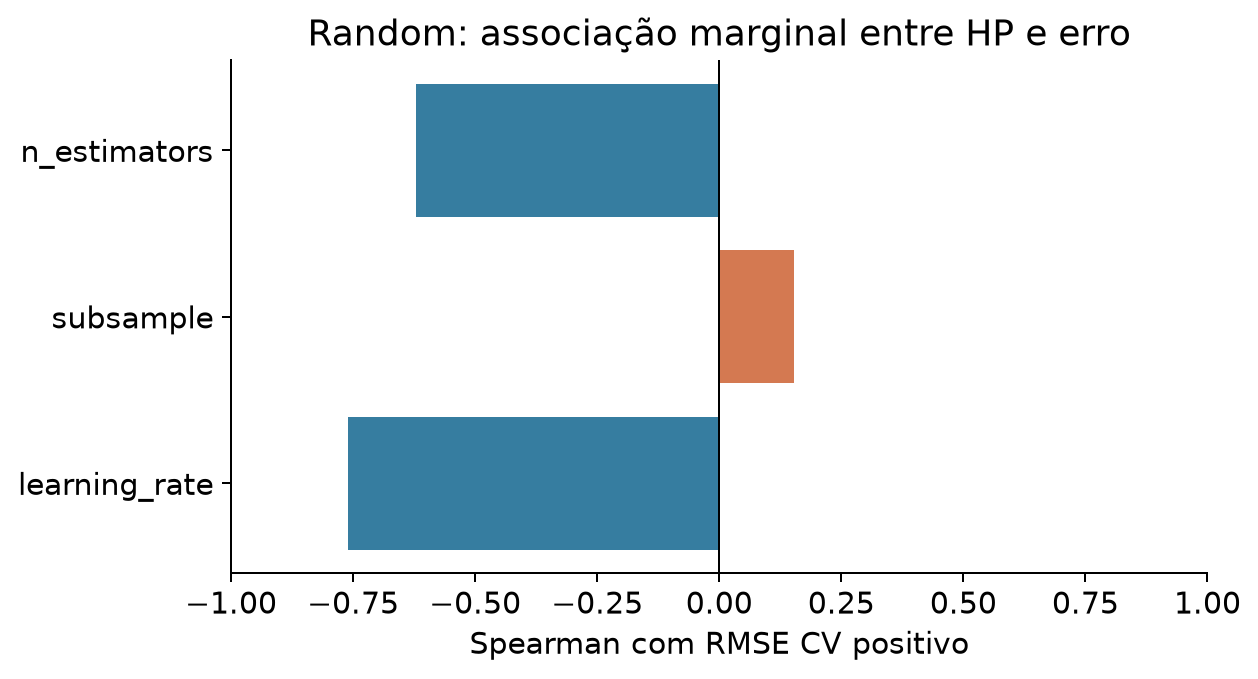

In [15]:
figure('06_random_spearman')

In [16]:
finding('spearman')

A maior associação marginal absoluta foi de learning_rate (rho=-0.759) com RMSE CV positivo. Sinal negativo associa valores maiores a erros menores. Correlação marginal não separa interações e não prova causalidade ou importância global.

In [17]:
finding('grid_preference')

Grid é útil quando há poucos hiperparâmetros, domínios discretos pequenos e necessidade de cobertura exaustiva e auditável. O número de combinações cresce multiplicativamente; a vantagem não é geral em dimensões maiores.

In [18]:
for row in analysis['metrics']:
    if row['method'] in ['baseline','grid','random']:
        display(Markdown('**'+row['method']+'** — parâmetros: `'+row['params_json']+'`; tempo de busca '+str(row['search_seconds'])+' s; refit '+str(row['refit_seconds'])+' s.'))

**baseline** — parâmetros: `{"learning_rate": 0.1, "n_estimators": 100, "subsample": 1.0}`; tempo de busca 0.2532746999058872 s; refit 0.0960010999115184 s.

**grid** — parâmetros: `{"learning_rate": 0.2, "n_estimators": 150, "subsample": 0.8}`; tempo de busca 3.9914890999207273 s; refit 0.1429754999699071 s.

**random** — parâmetros: `{"learning_rate": 0.2, "n_estimators": 150, "subsample": 0.8}`; tempo de busca 3.288482400006614 s; refit 0.1239108999725431 s.

### Exercício 2 — GP manual, bibliotecas e metaheurísticas

**Item 6.** GP Matérn 5/2, cinco pontos iniciais e dez aquisições EI, n_estimators=100. A aquisição é maximizada aproximadamente numa malha 61×61. Cada figura mostra o posterior anterior à avaliação seguinte: média/σ em 2D, corte no subsample do candidato e EI no mesmo corte. Só observações exatamente nesse corte aparecem nele.

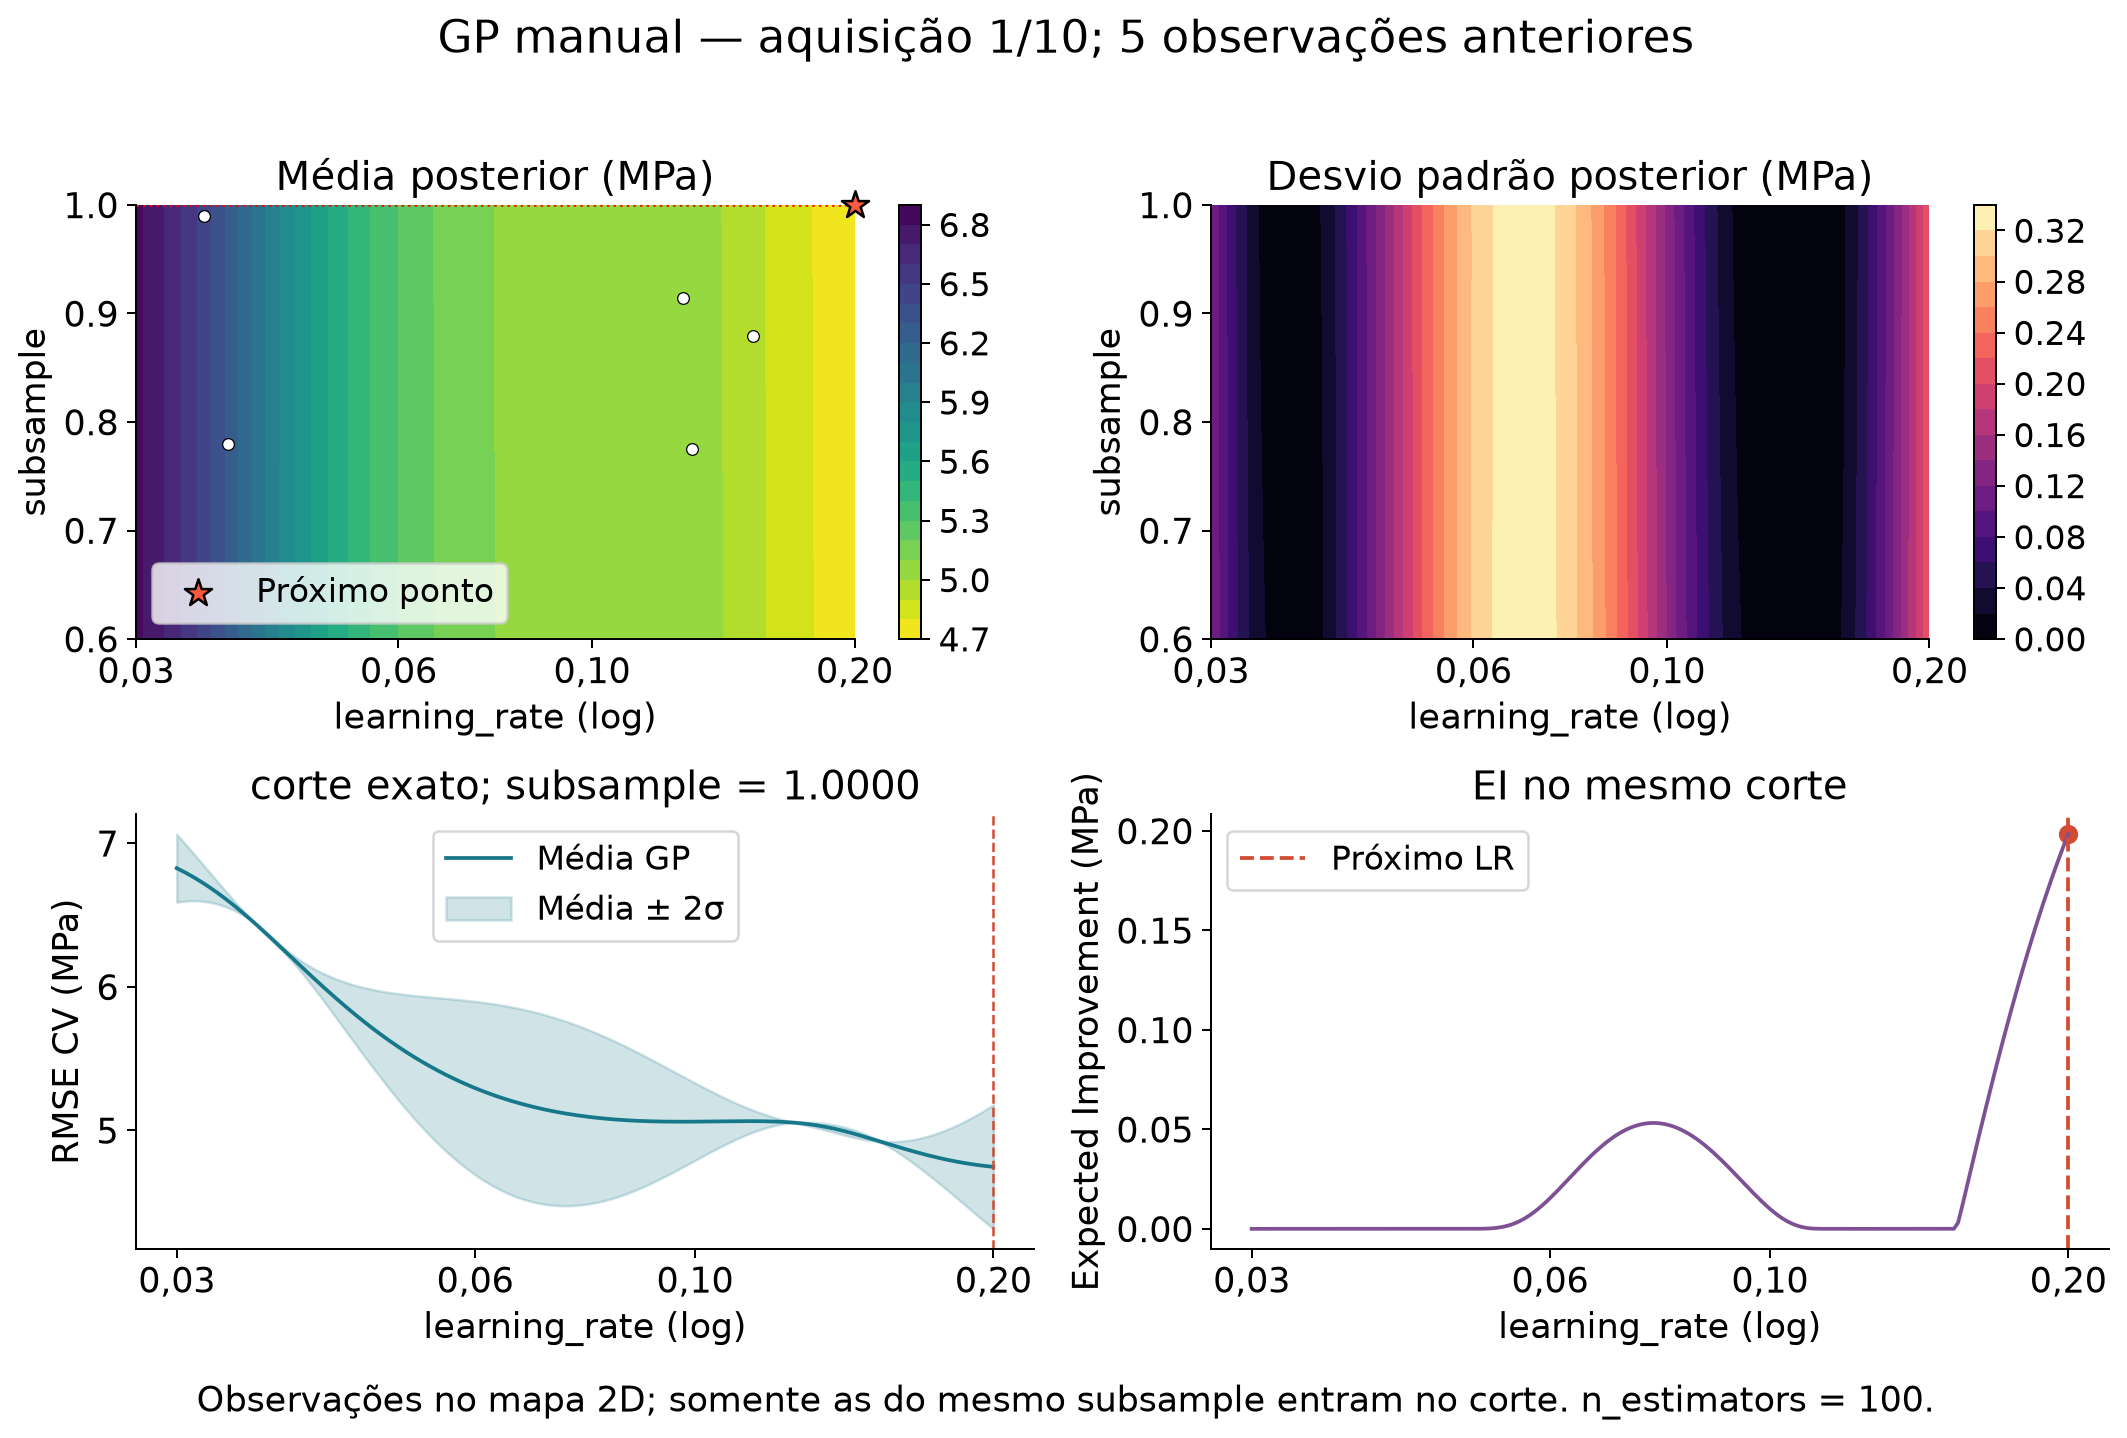

In [19]:
figure('gp_iteration_01')

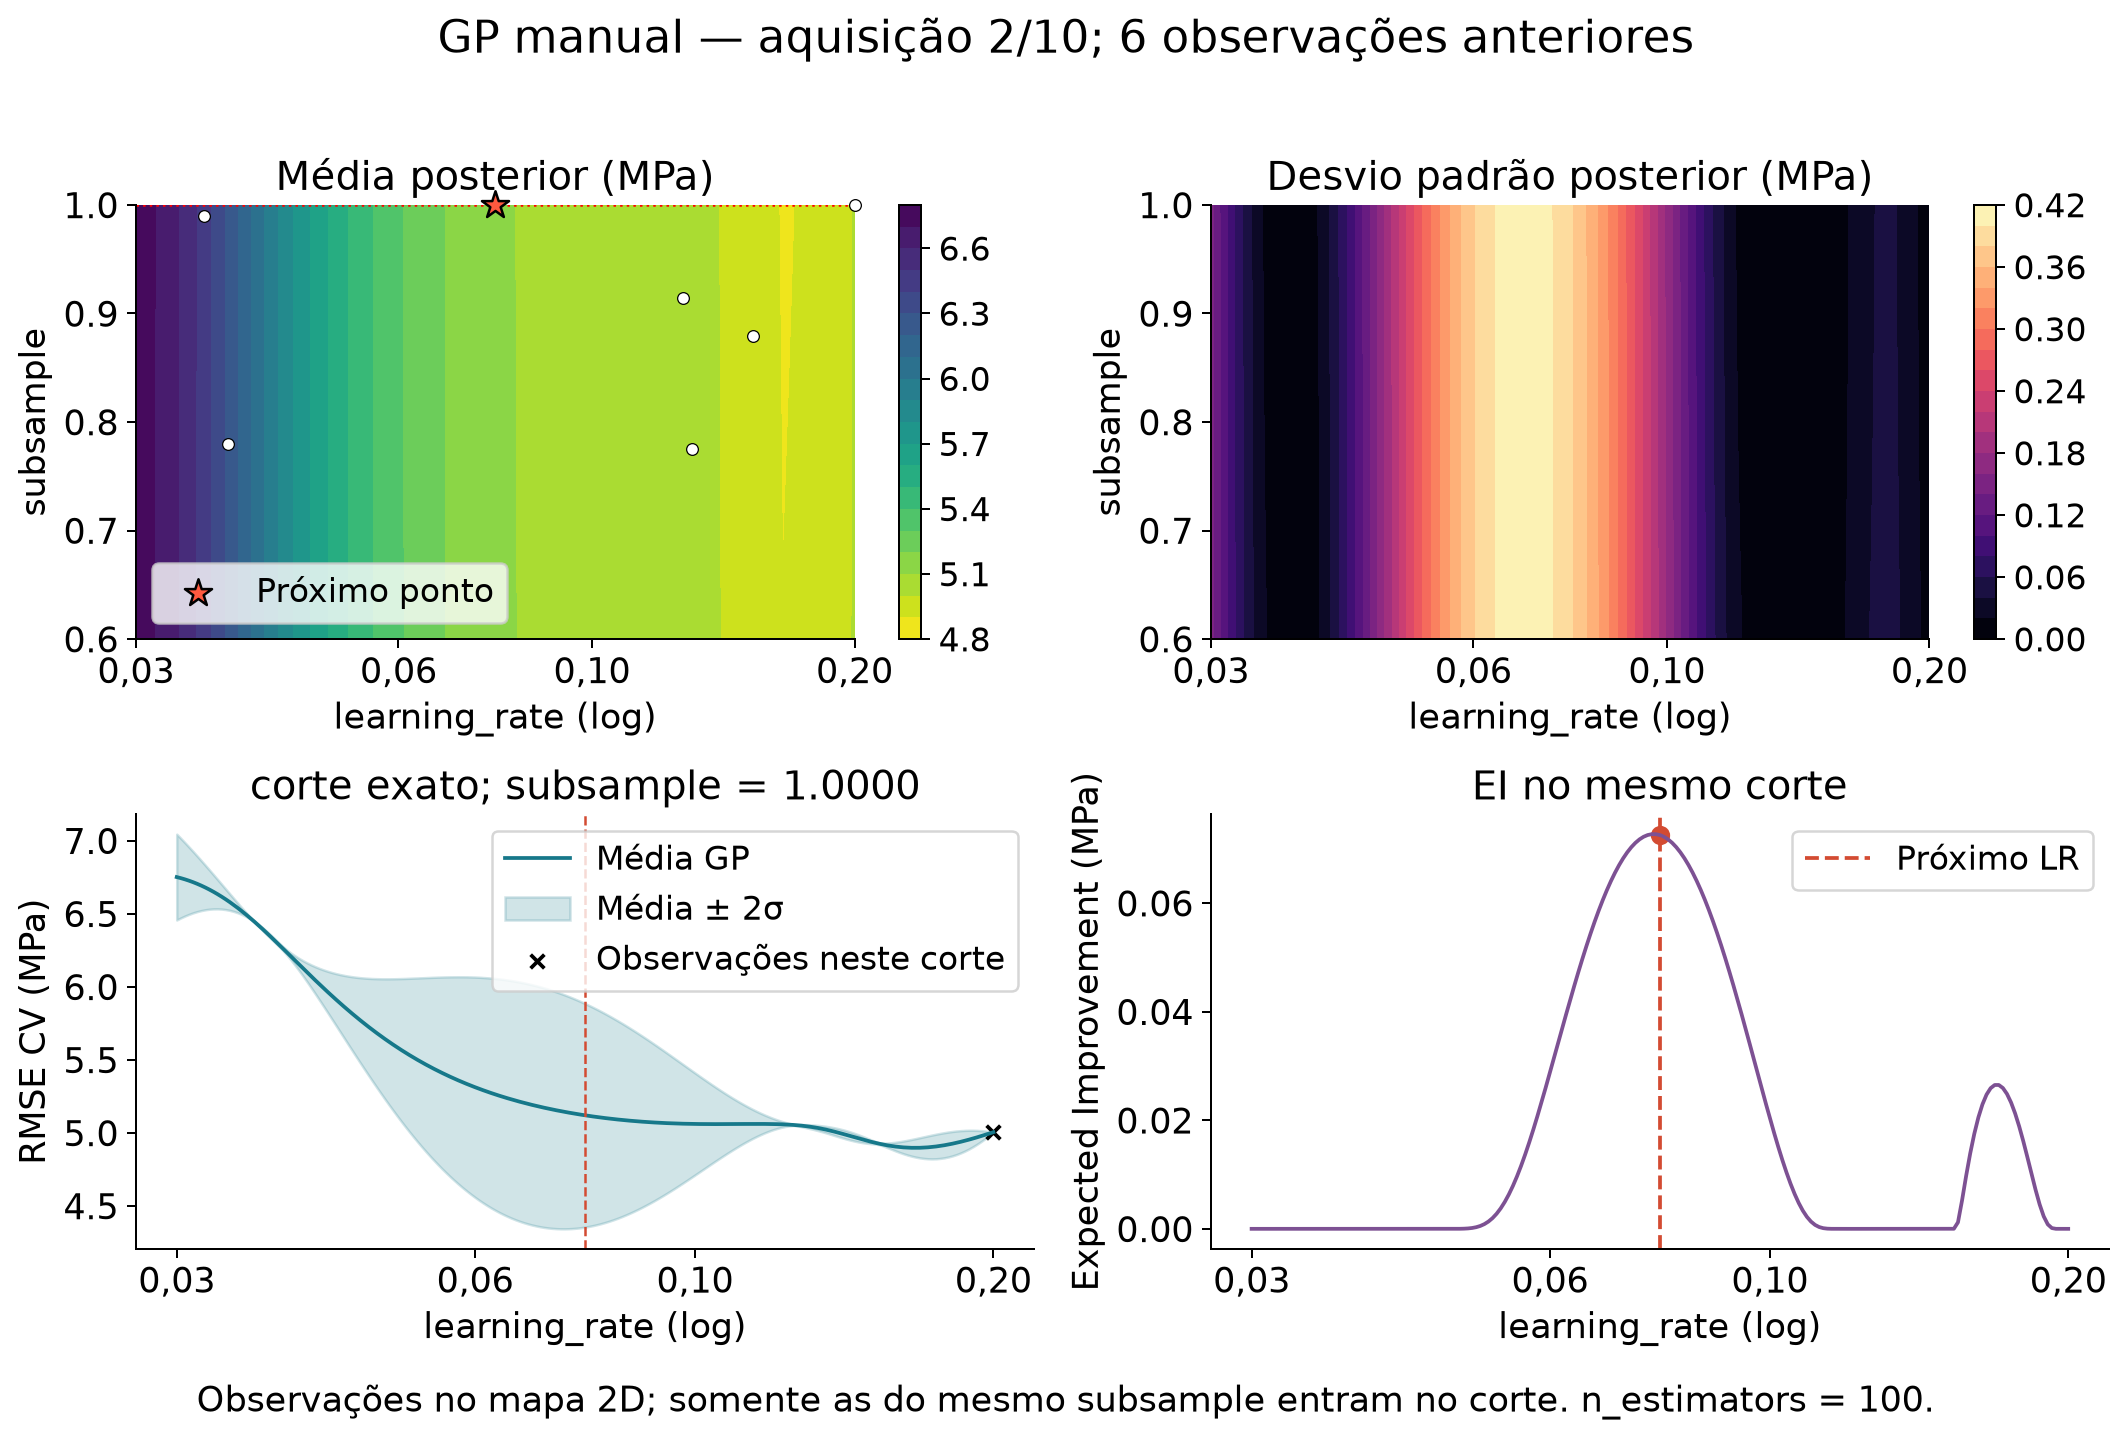

In [20]:
figure('gp_iteration_02')

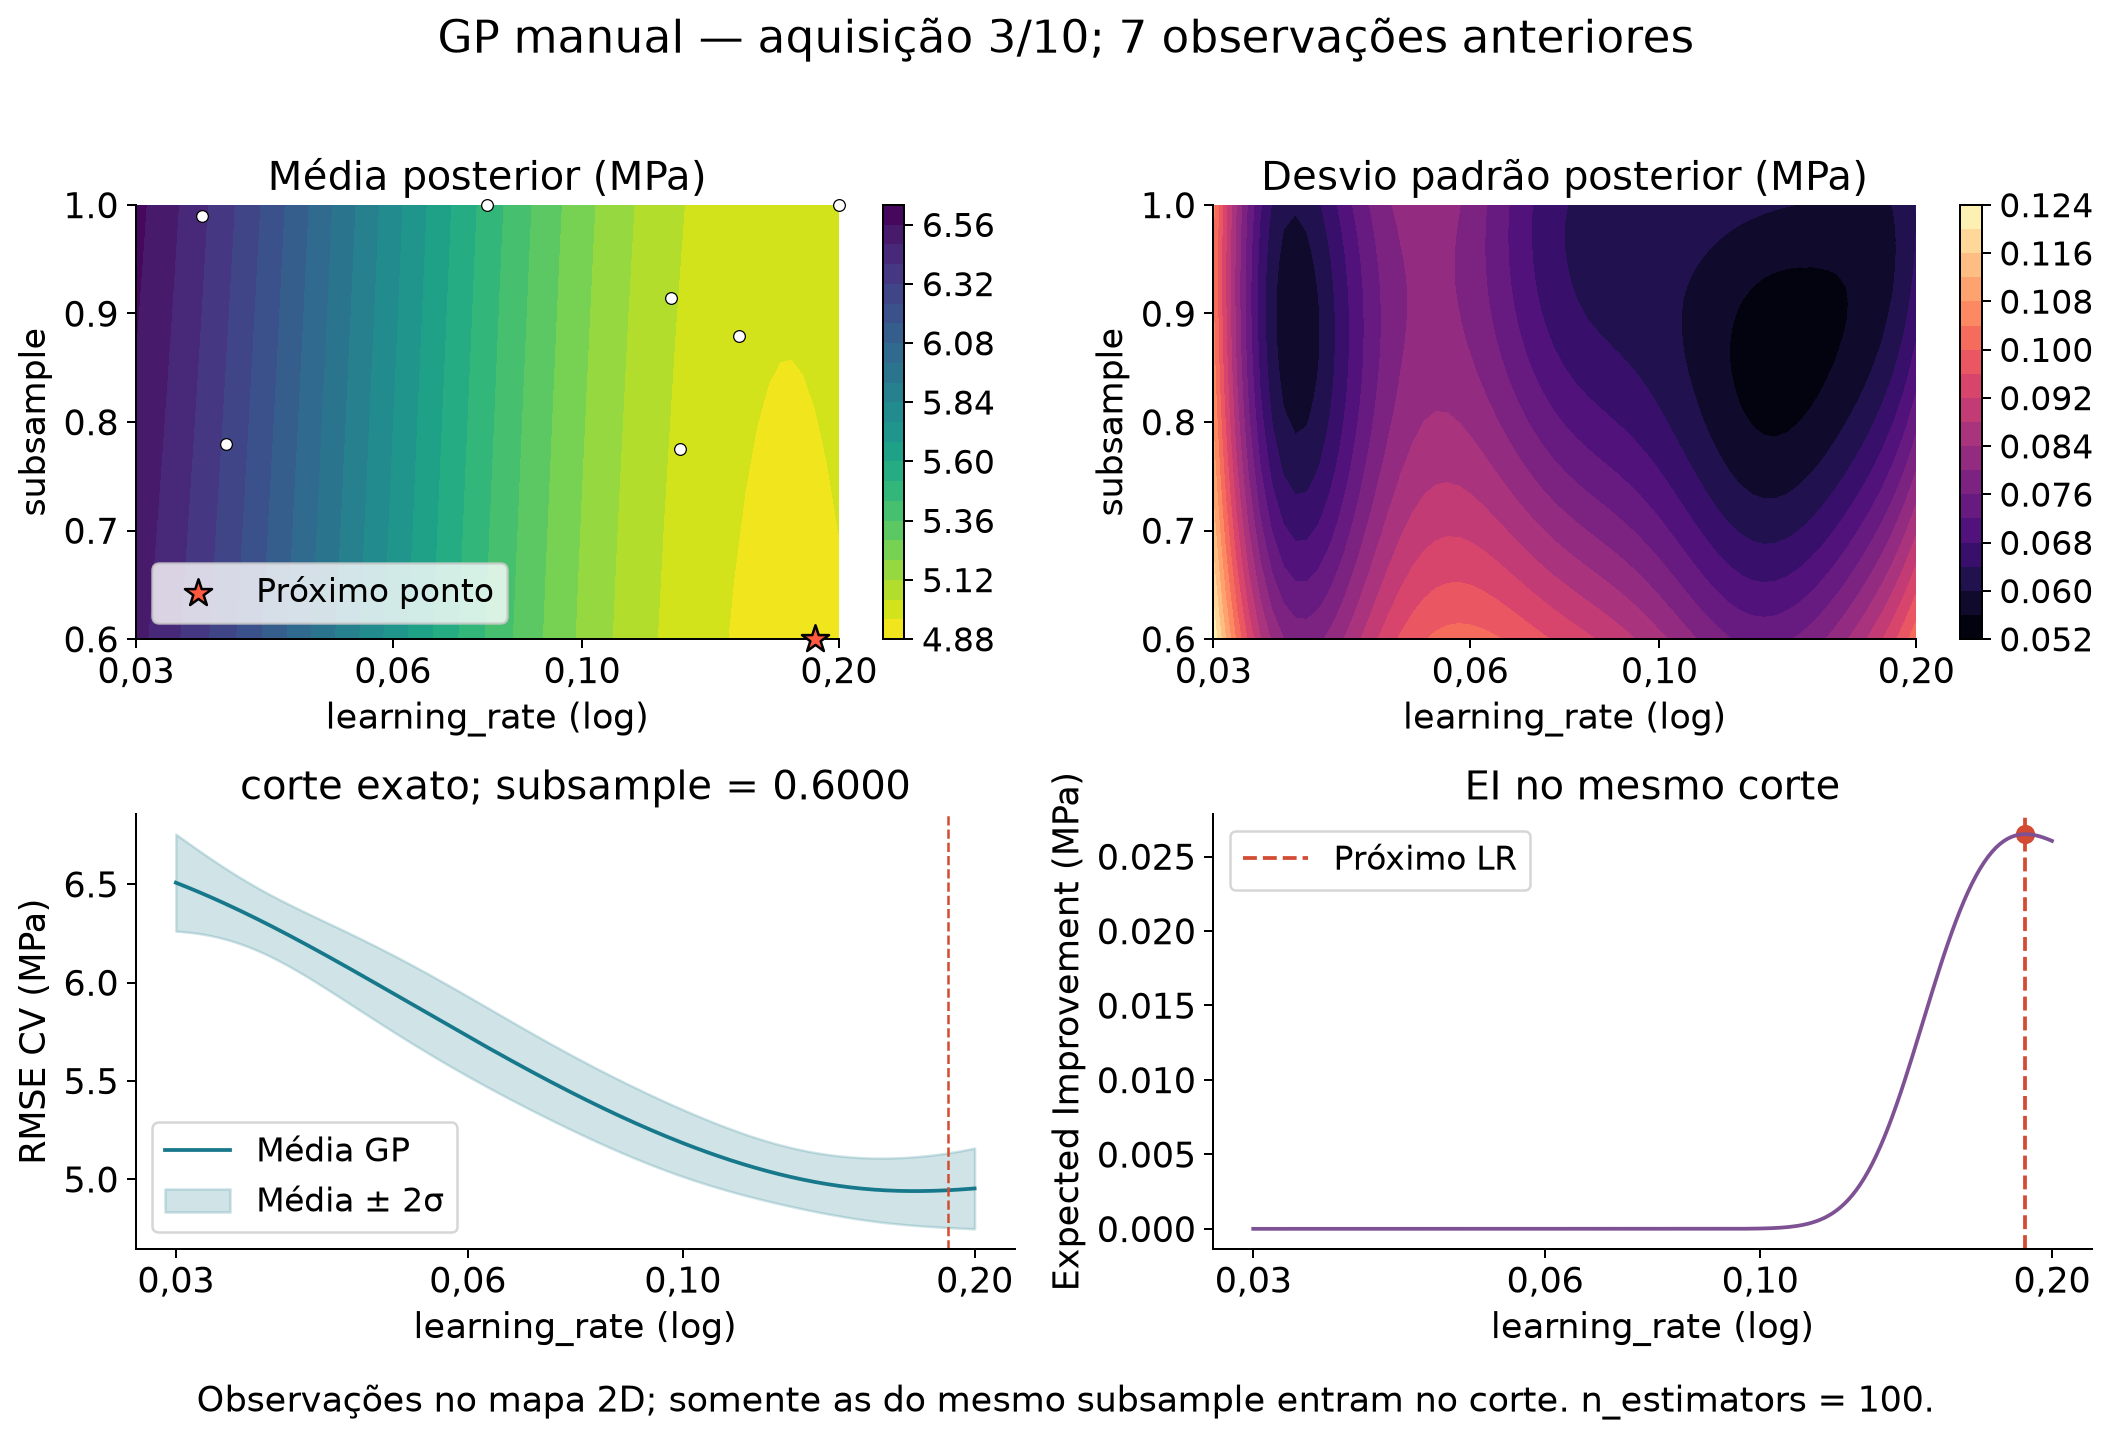

In [21]:
figure('gp_iteration_03')

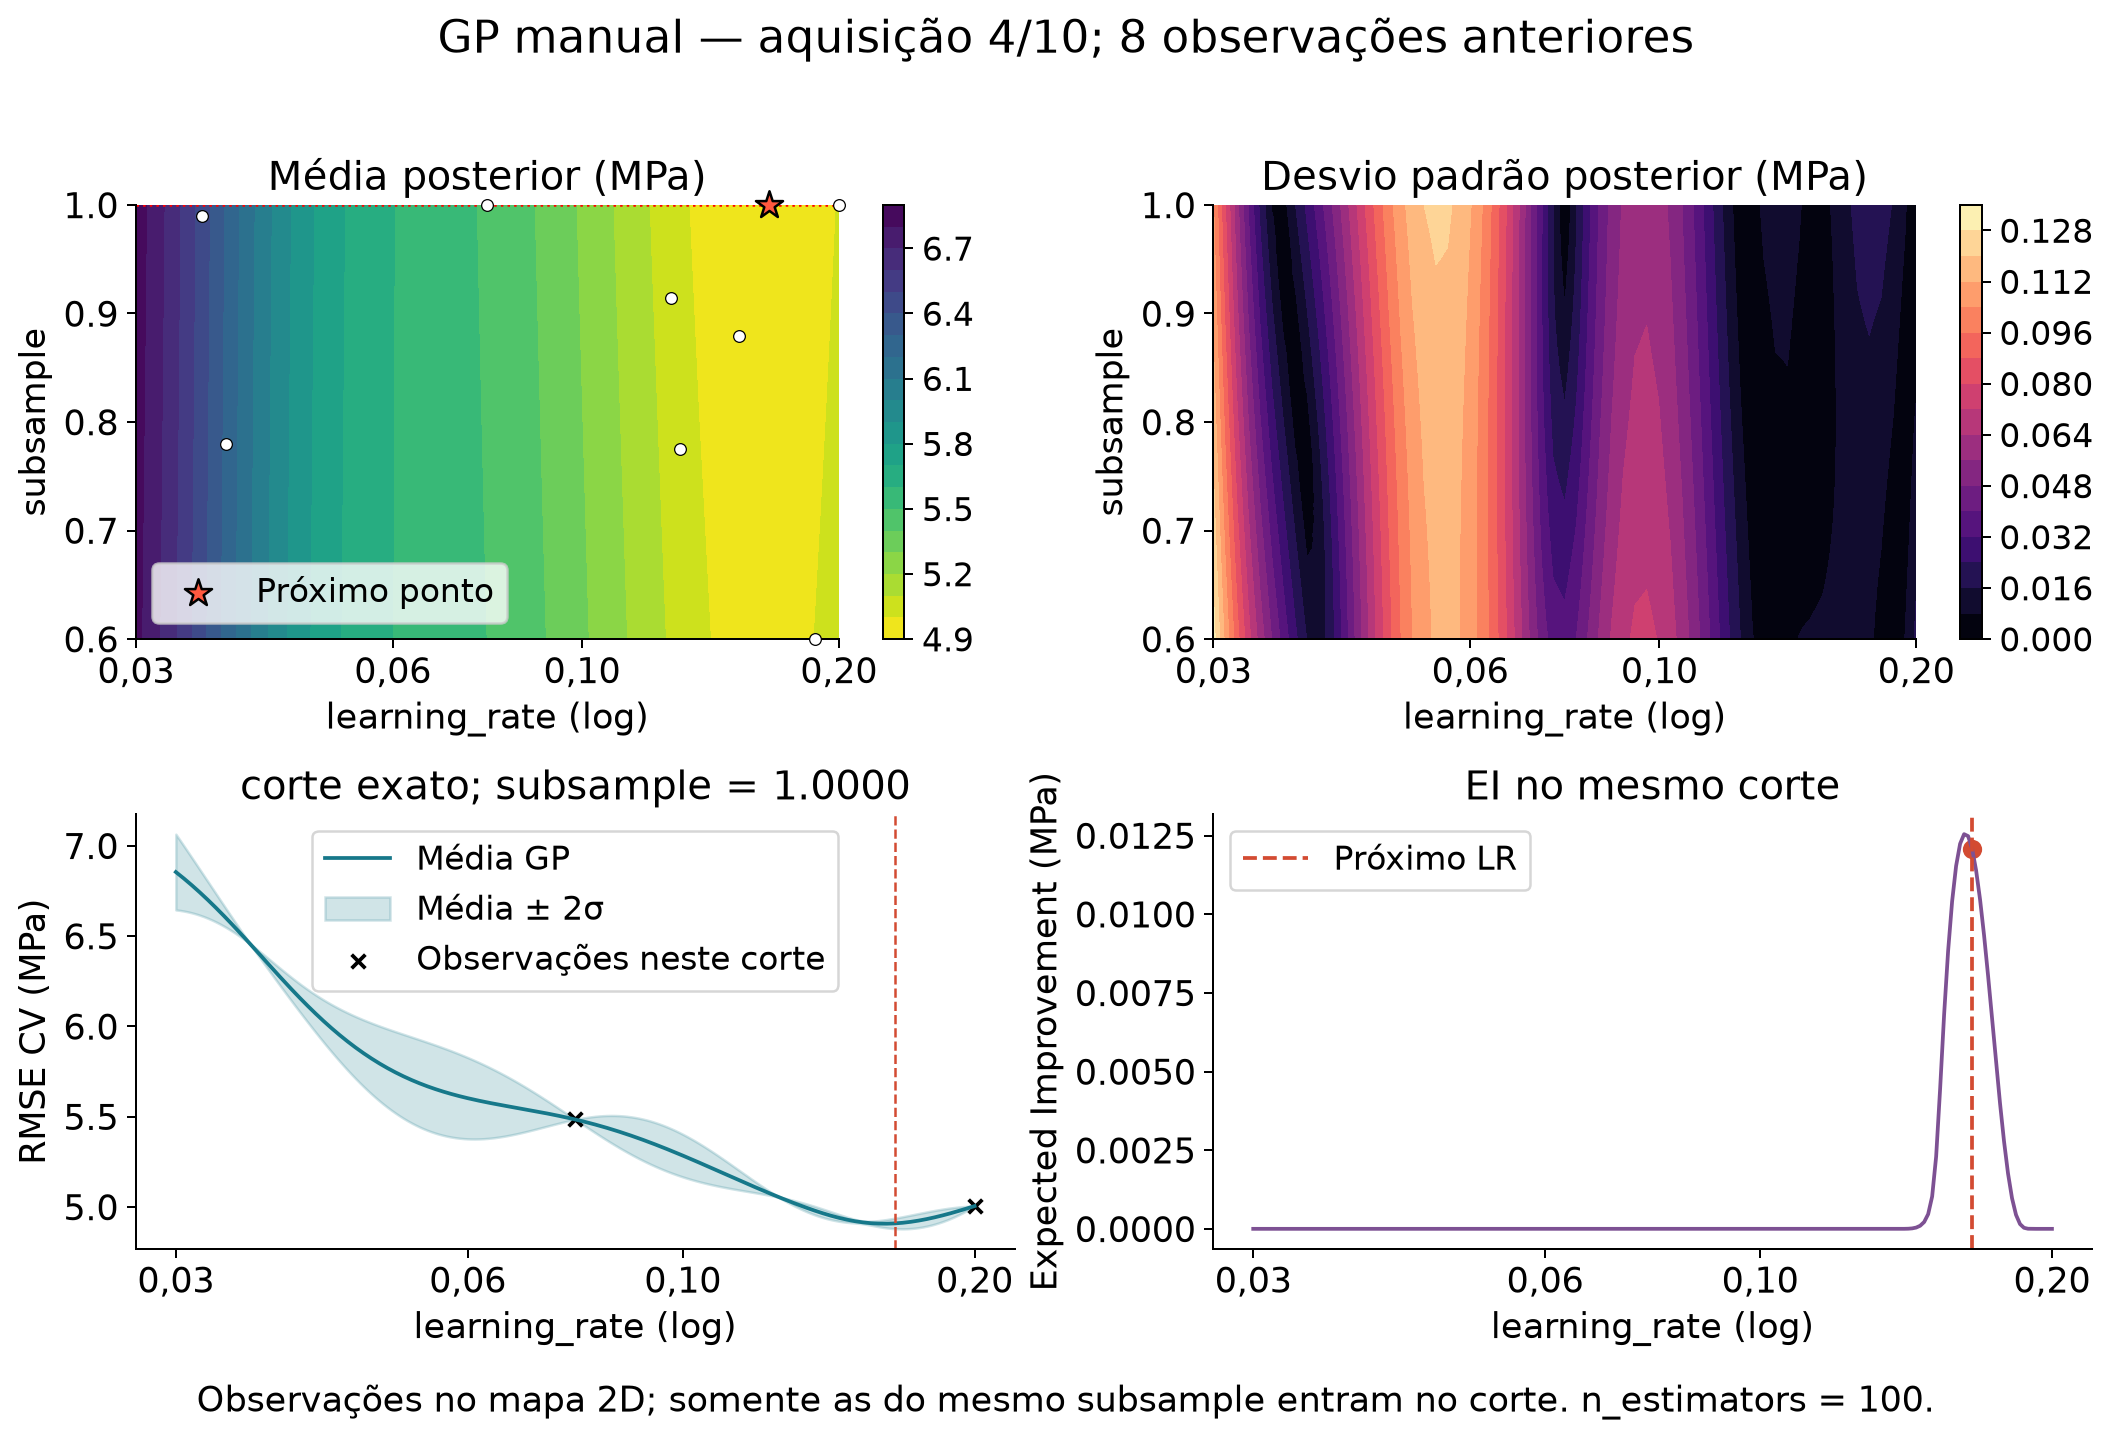

In [22]:
figure('gp_iteration_04')

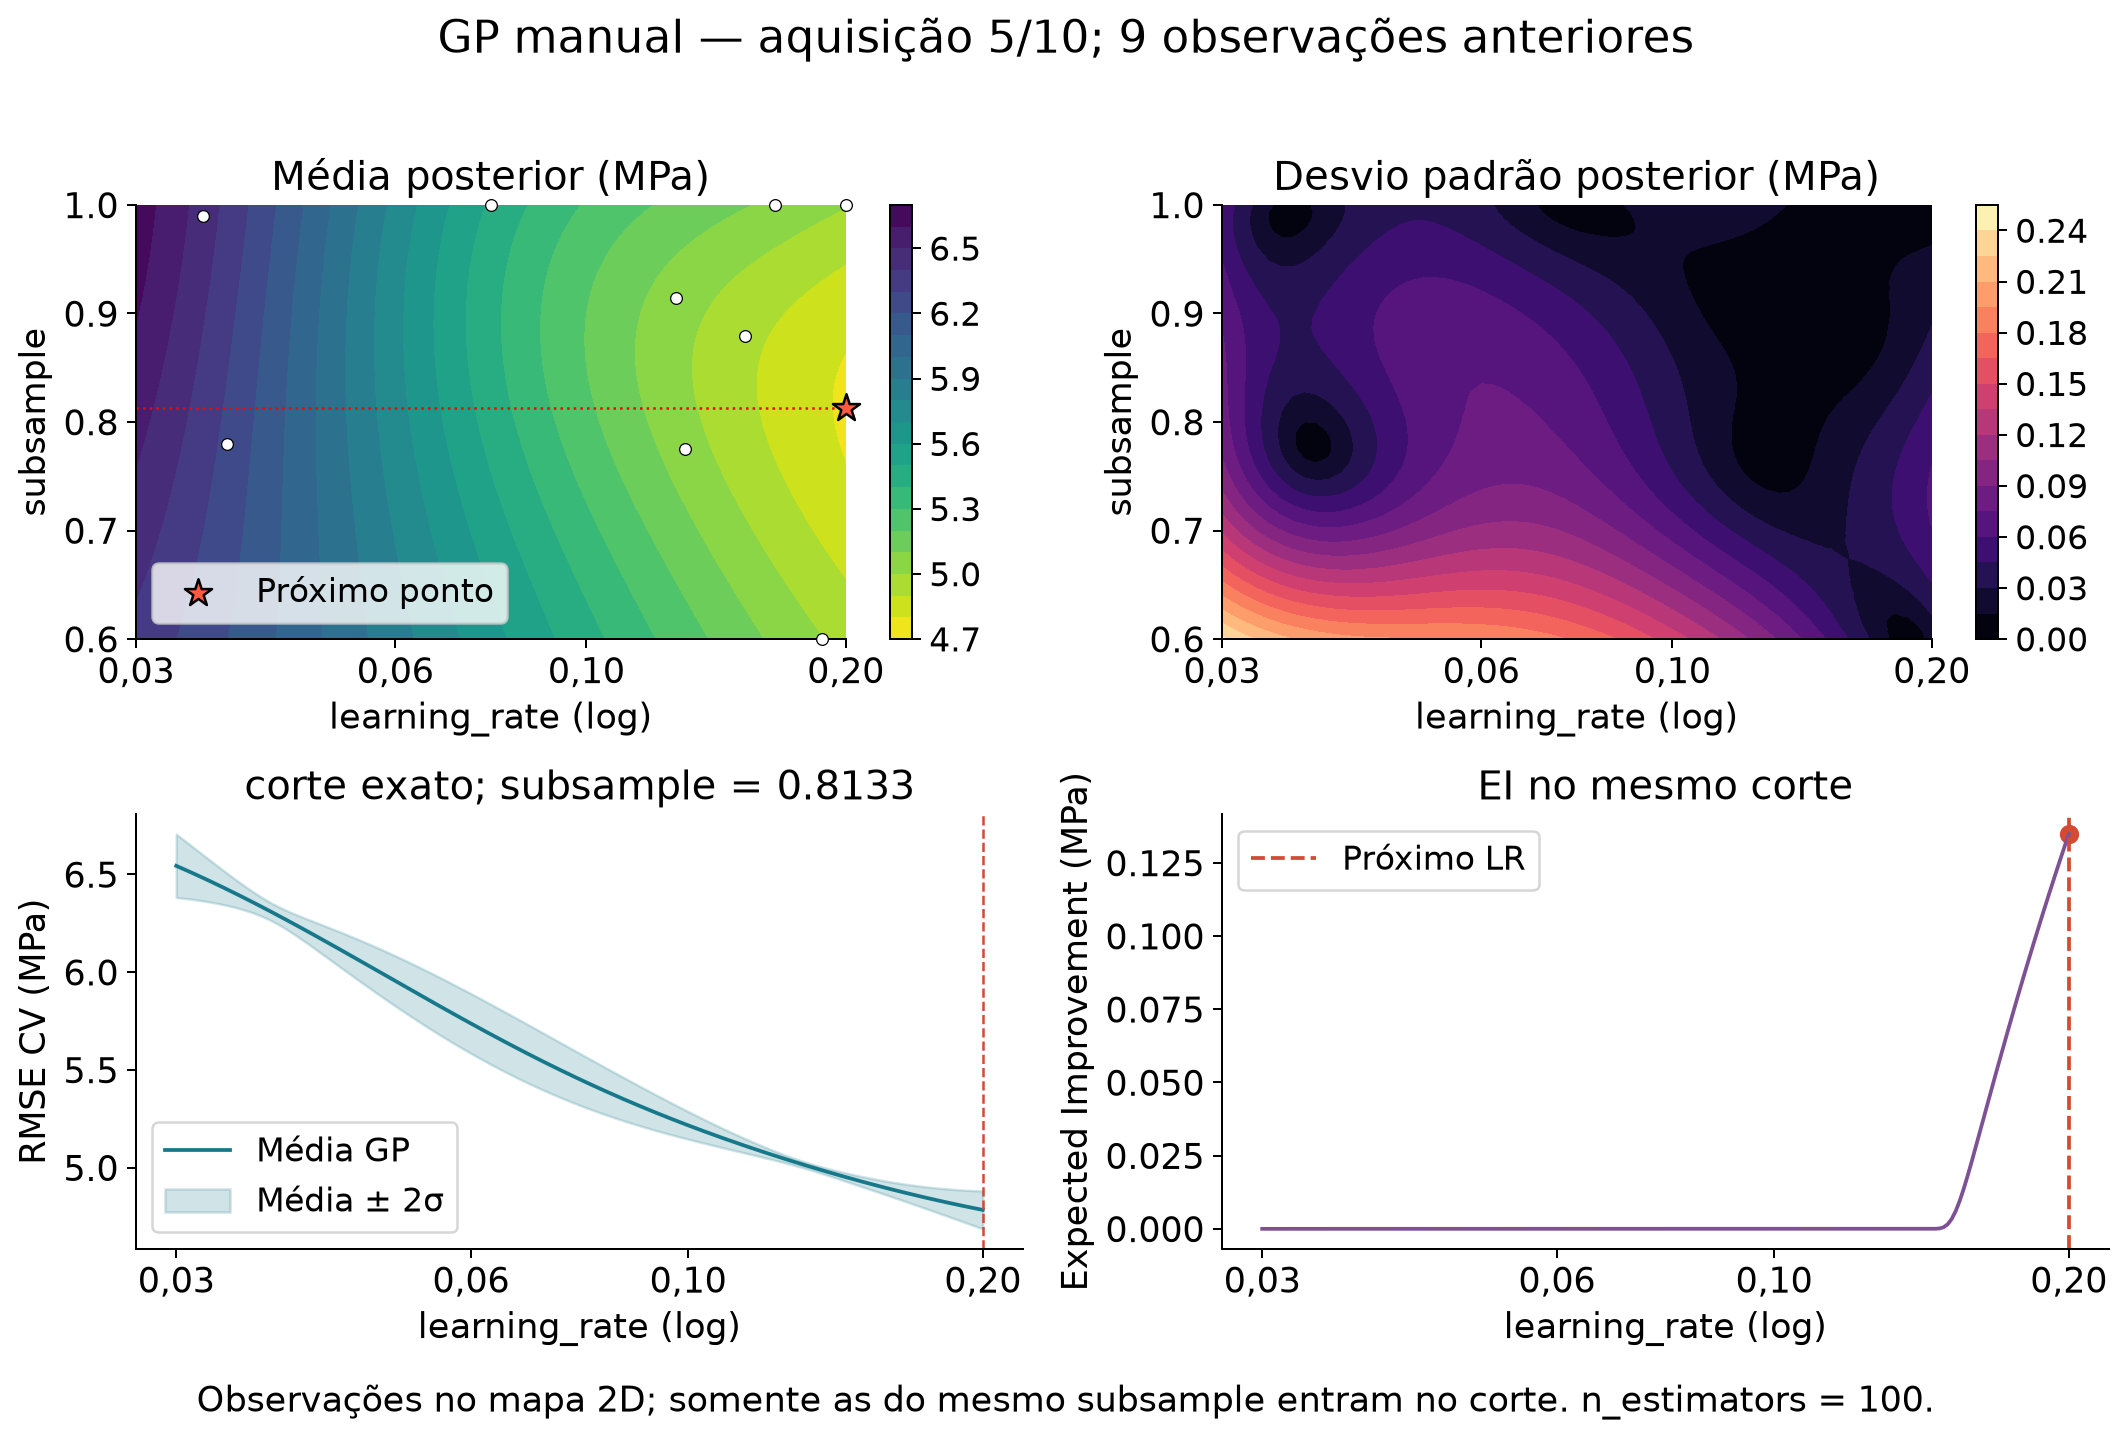

In [23]:
figure('gp_iteration_05')

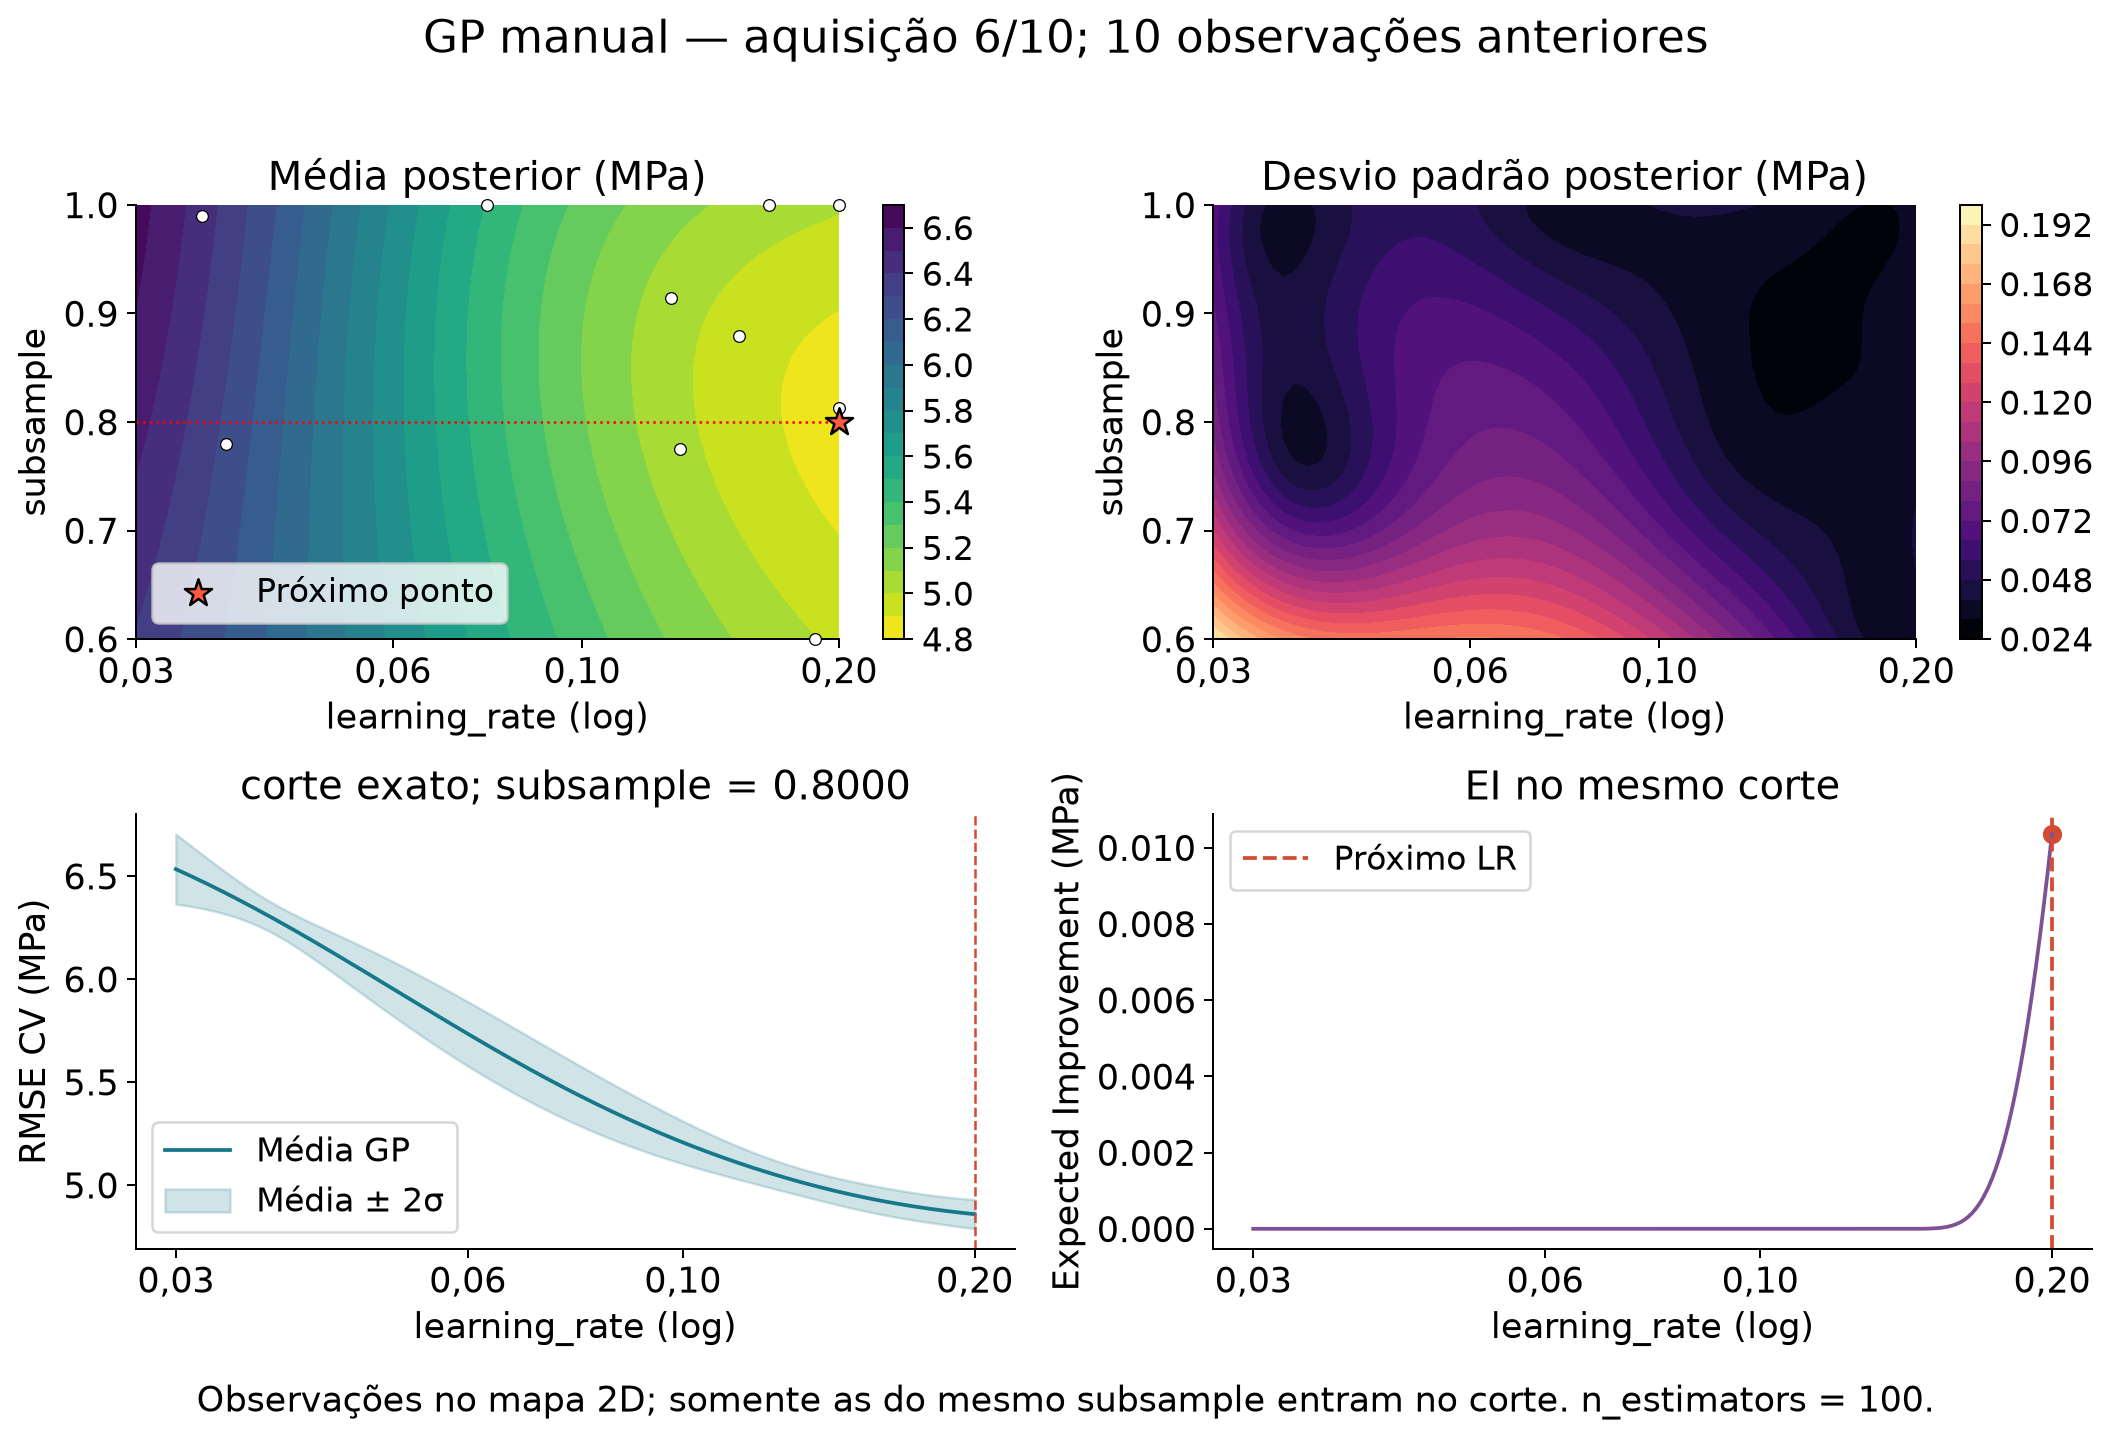

In [24]:
figure('gp_iteration_06')

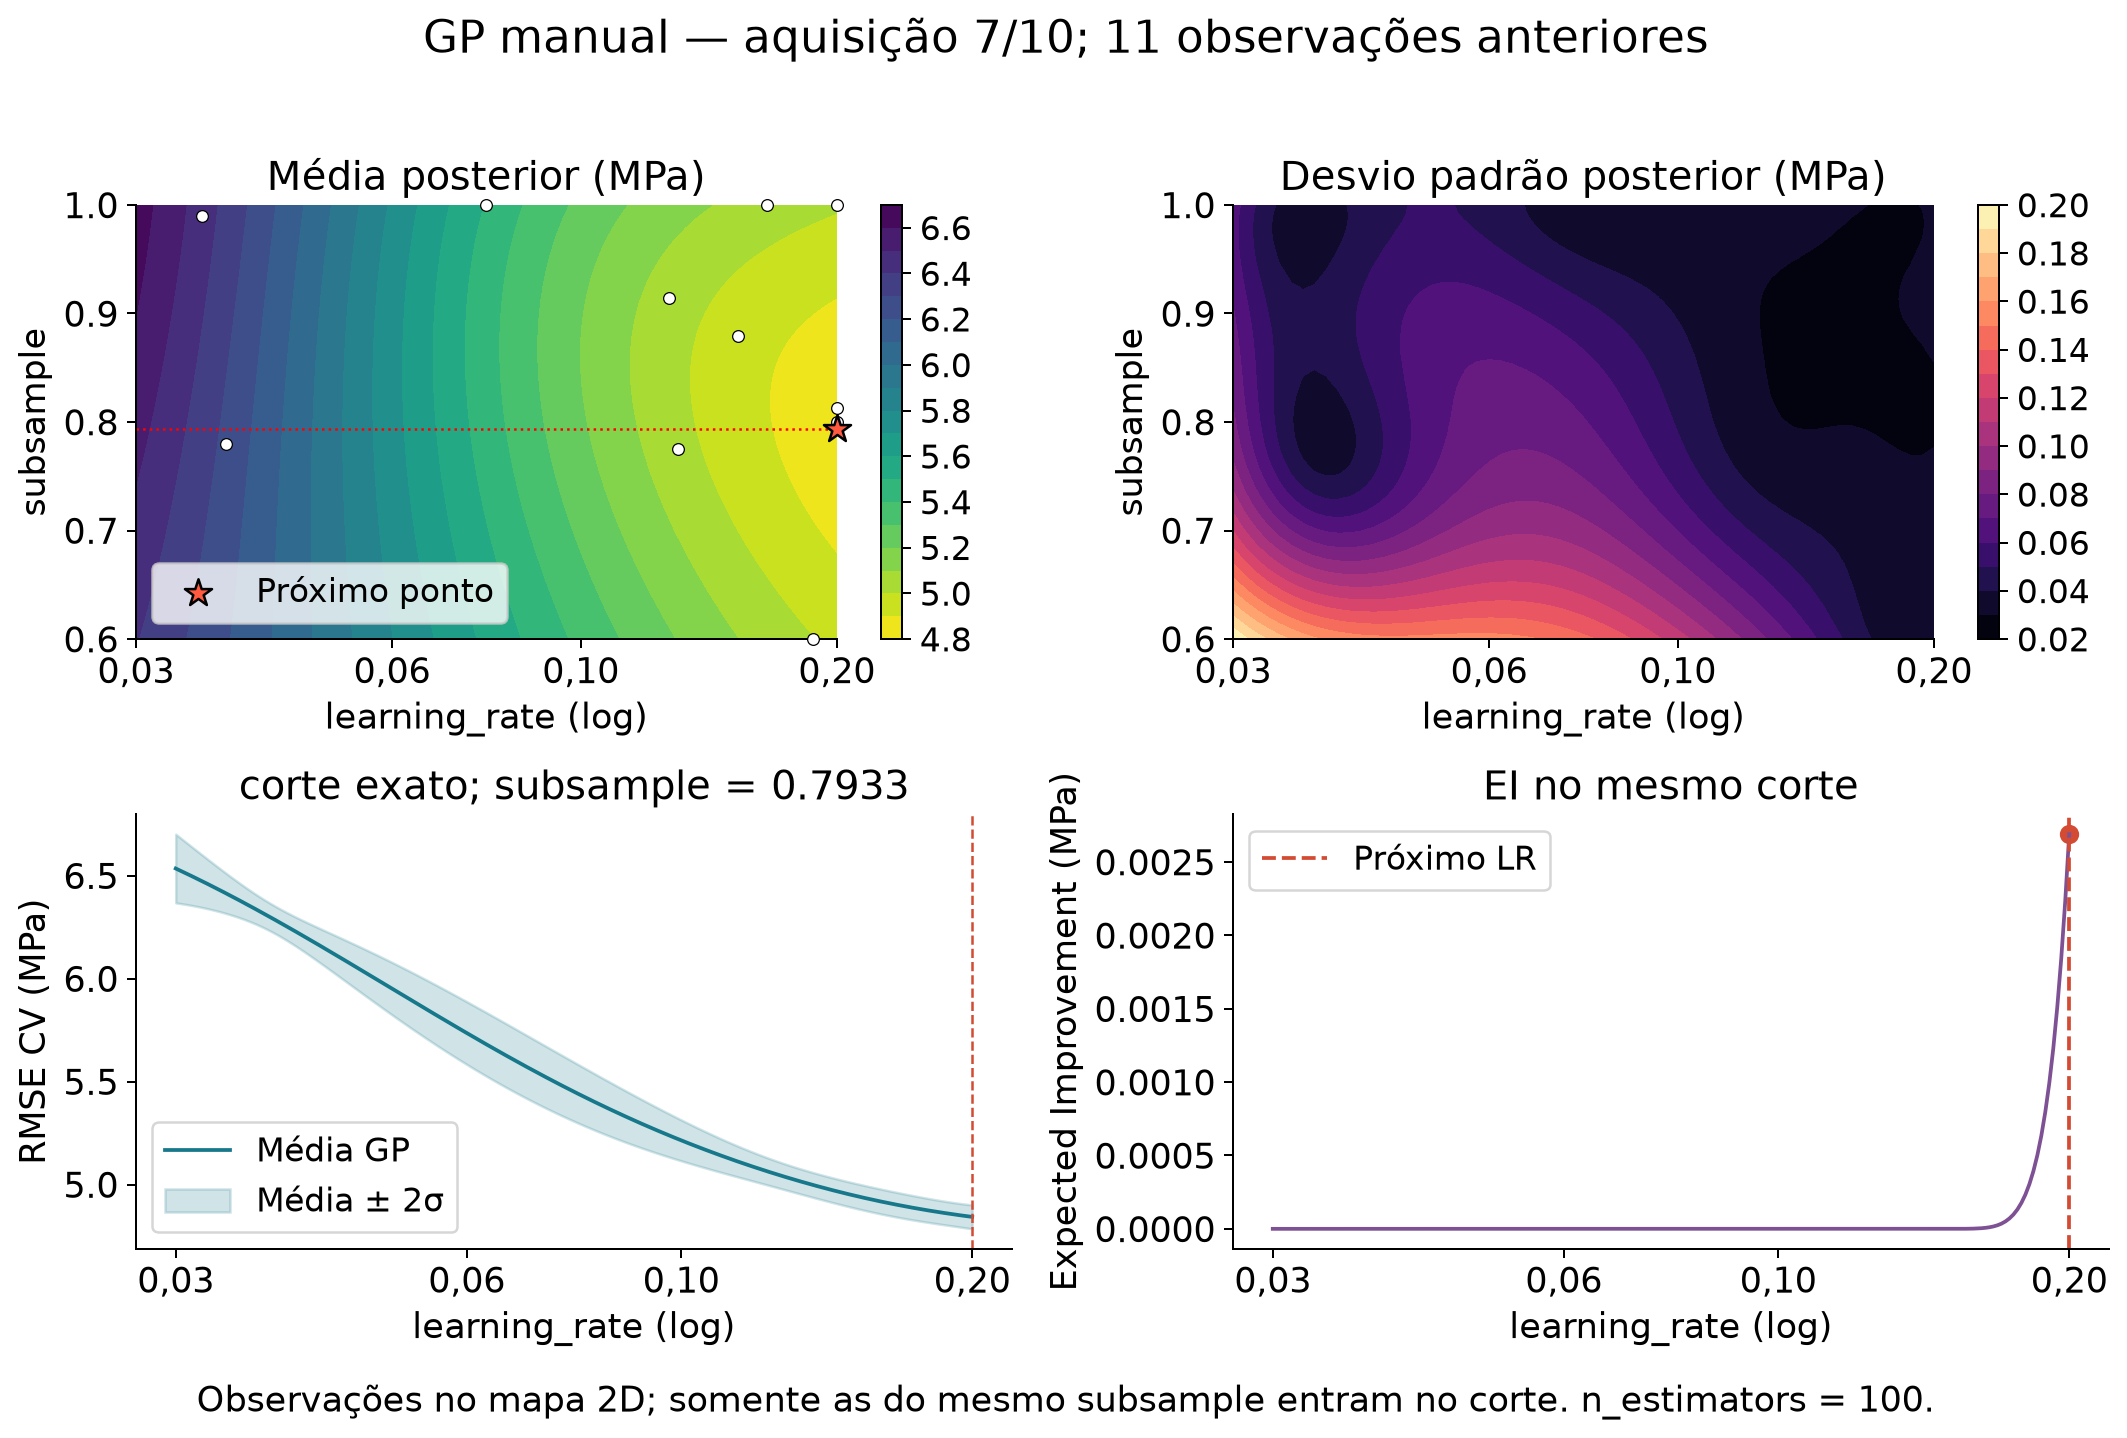

In [25]:
figure('gp_iteration_07')

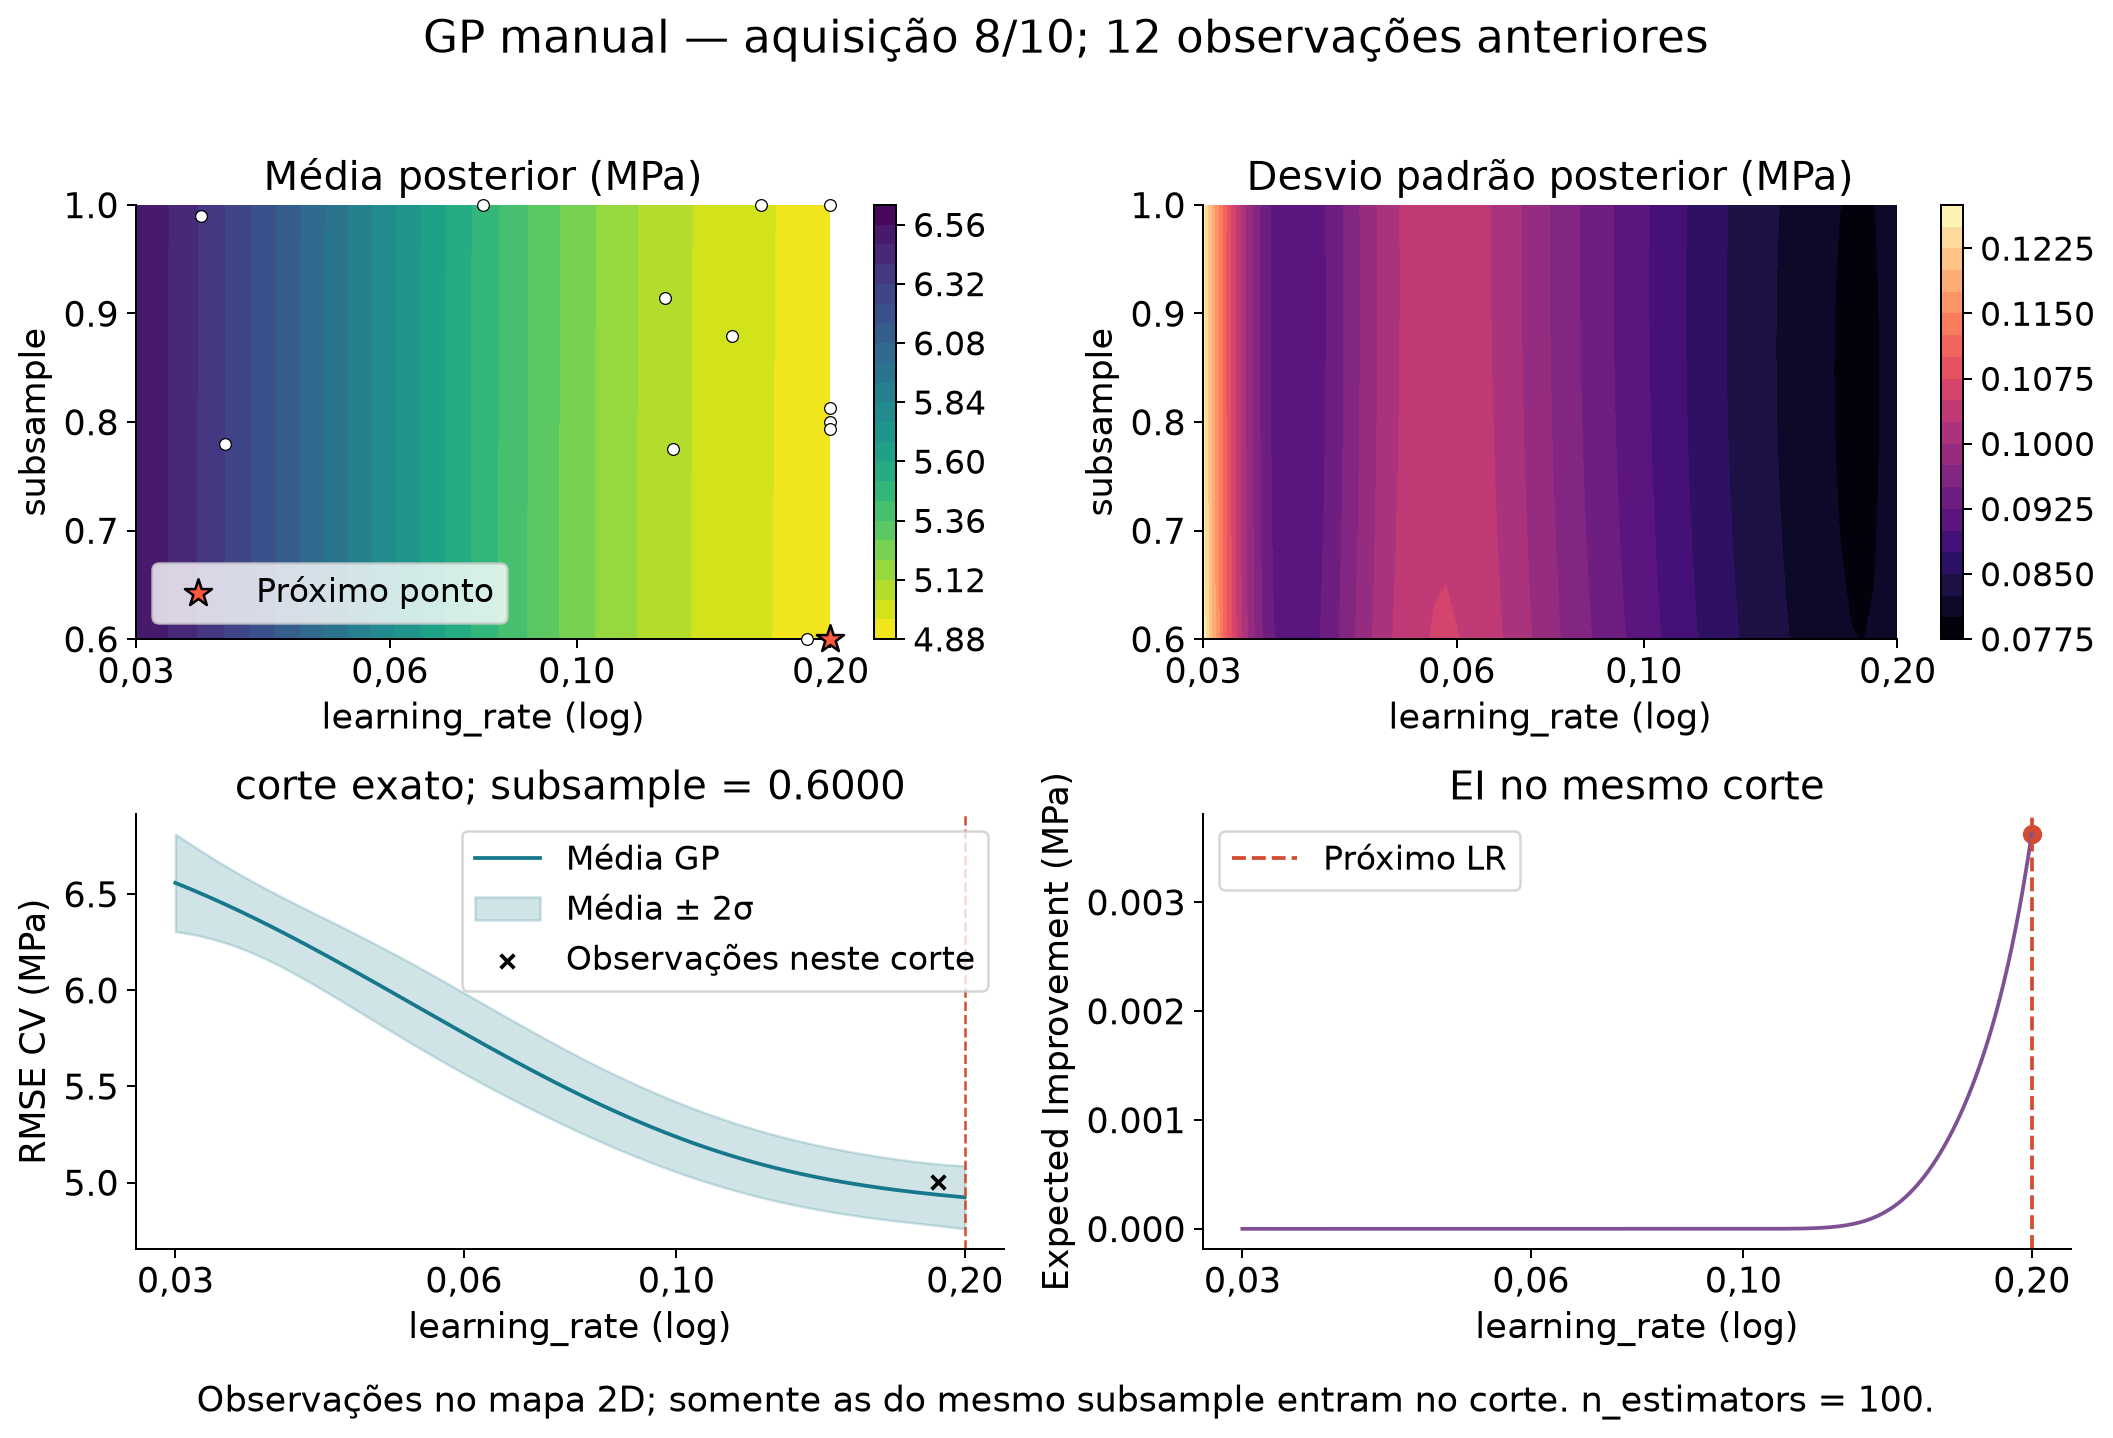

In [26]:
figure('gp_iteration_08')

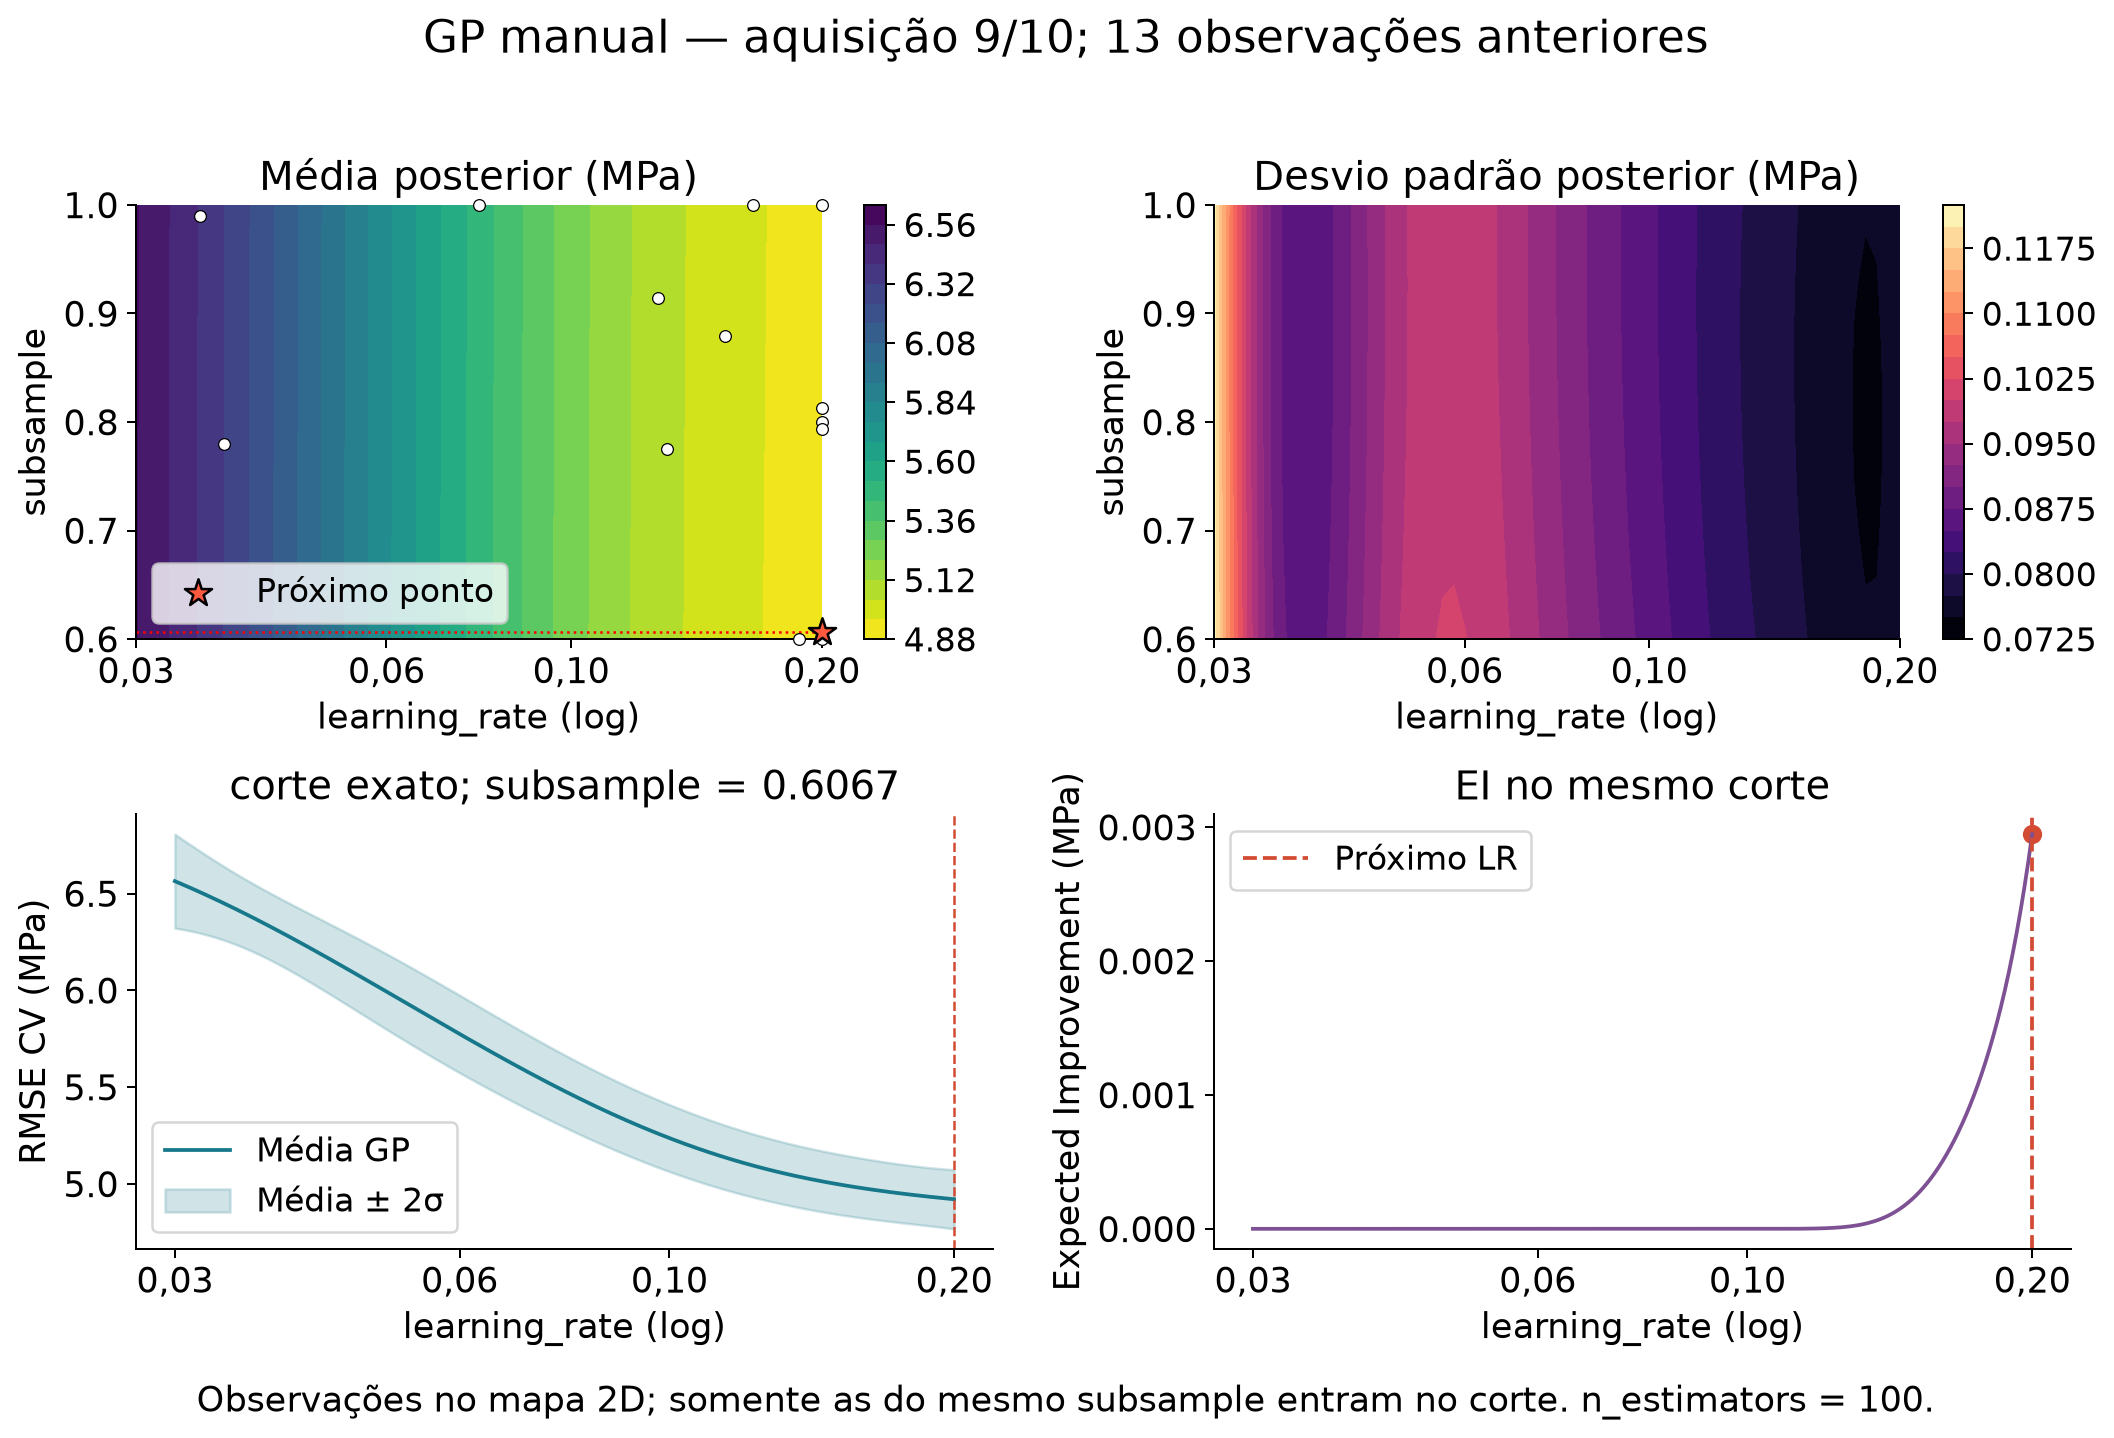

In [27]:
figure('gp_iteration_09')

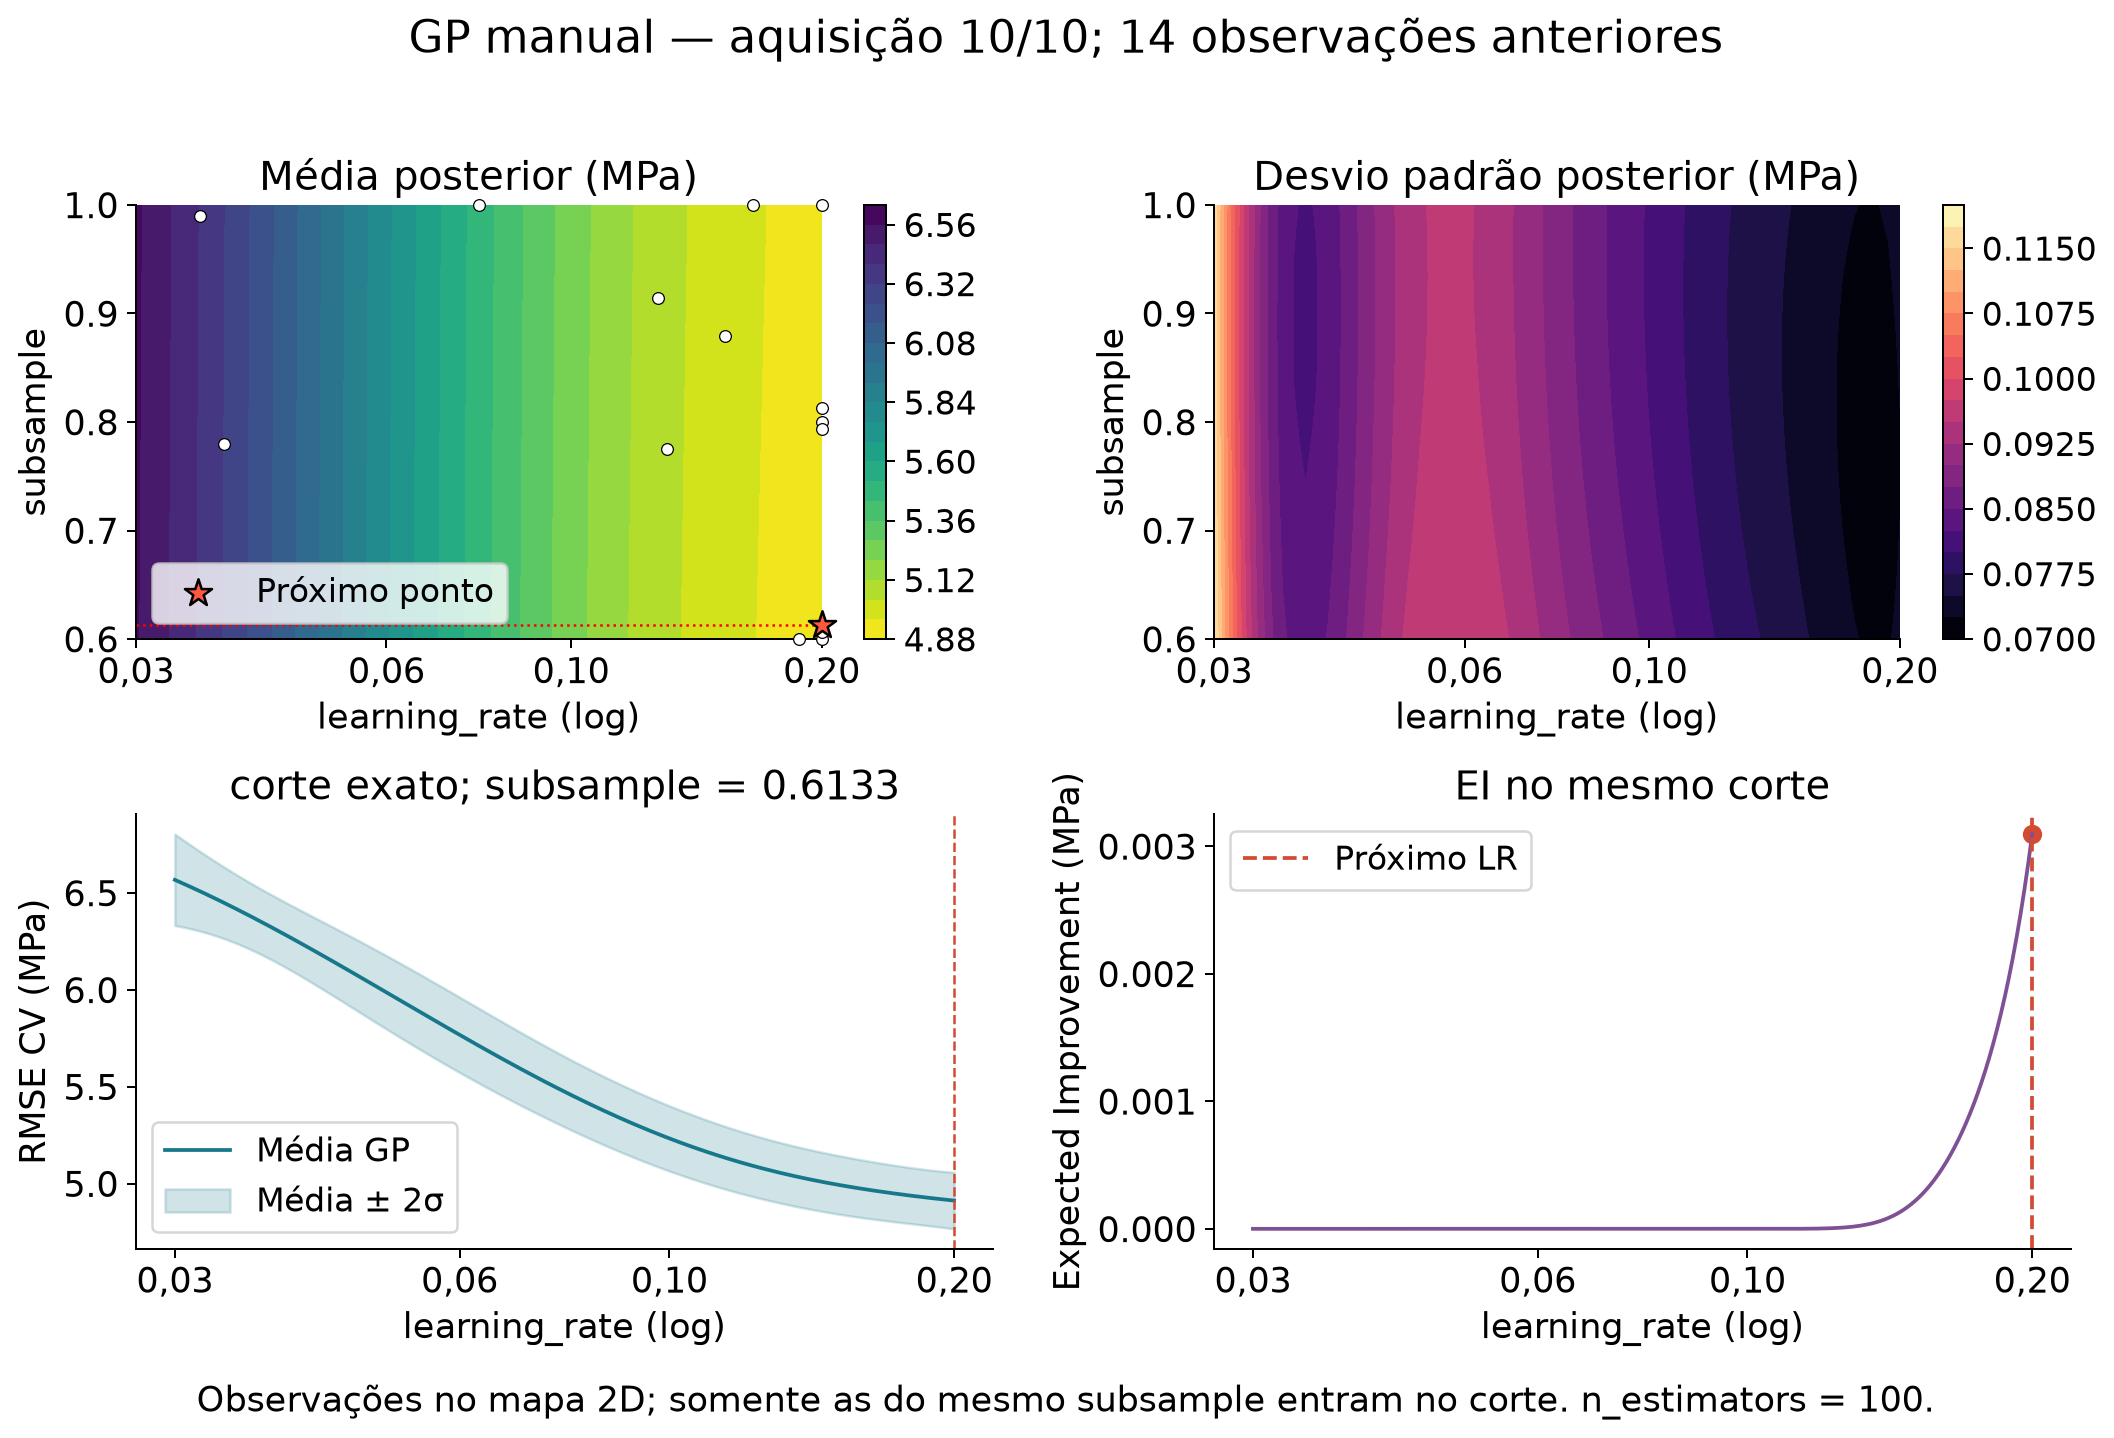

In [28]:
figure('gp_iteration_10')

In [29]:
finding('gp')

A incerteza média posterior na malha passou de 0.1357 para 0.0856 MPa entre os posteriors anterior à primeira e à décima aquisição. A mudança pode não ser monotônica, pois o kernel é reajustado. O melhor RMSE já observado nesses instantes passou de 4.9288 a 4.8254 MPa. EI combina redução esperada do erro e incerteza; a maximização é aproximada na malha de 61 × 61 pontos, com xi = 0,01 MPa fixo. Não há garantia de ótimo global em 15 avaliações; o corte com 201 pontos apenas visualiza o posterior.

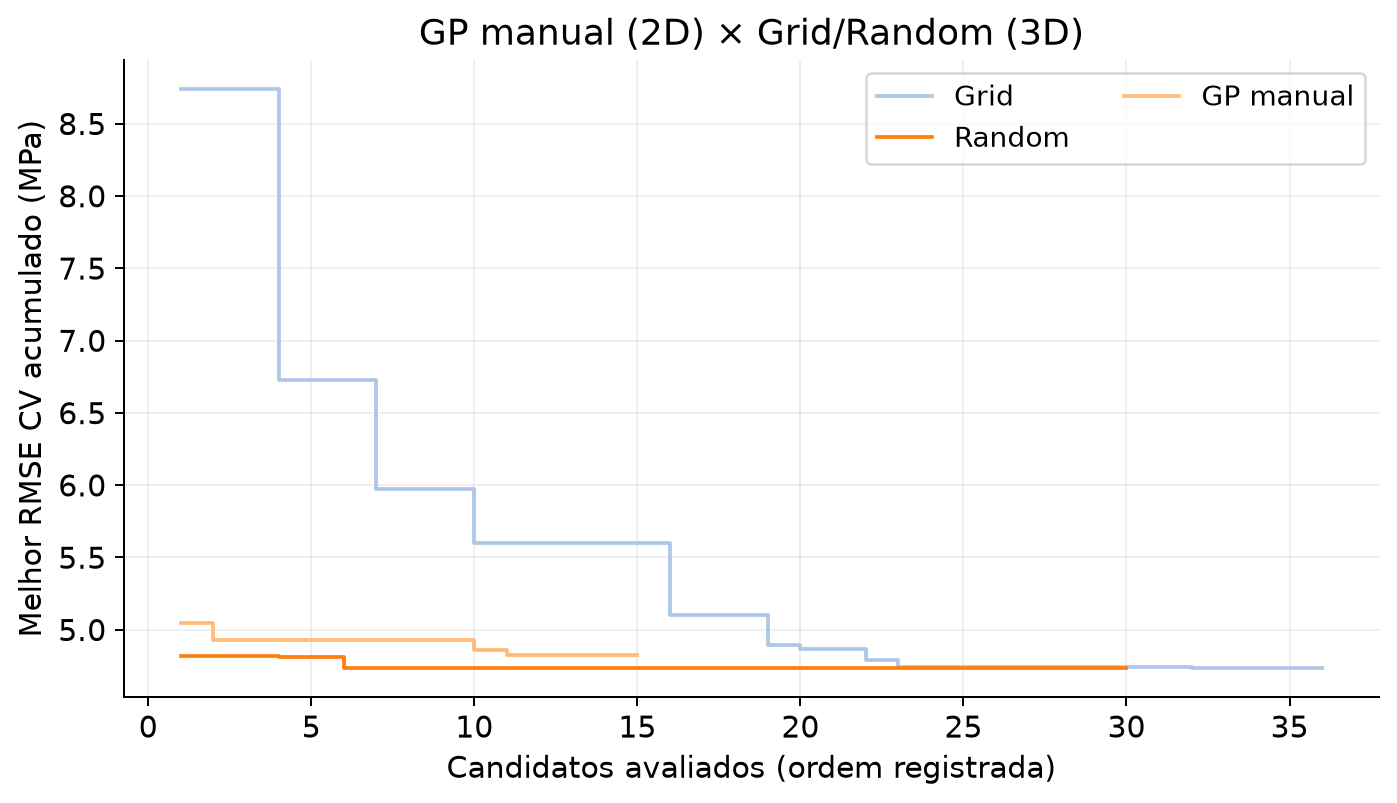

In [30]:
figure('07_gp_comparison')

In [31]:
methods(['grid','random','gp_manual'])

method,cv_rmse,test_rmse,test_mae,test_r2,total_seconds,n_evaluations
grid,4.73269,4.46302,3.14114,0.933232,4.13446,36
random,4.73269,4.46302,3.14114,0.933232,3.41239,30
gp_manual,4.82543,4.6763,3.43287,0.926698,2.07987,15


**Item 7.** skopt GP+EI/Matérn 5/2; bayes_opt GP+UCB κ=2,576; Optuna TPE; Hyperopt TPE/loguniform; Ray Tune OptunaSearch+ASHA. São 40 trials por biblioteca. Ray reporta recursos 0,25/0,50/0,75/1,00 com warm_start; apenas trials completos podem vencer. A tabela separa avaliações completas, podas e trabalho CV real.

In [32]:
table_rows([r for r in analysis['metrics'] if r['method'] in ['bayessearch','bayesopt','optuna','hyperopt','ray']],['method','cv_rmse','test_rmse','total_seconds','n_evaluations','completed_trials','pruned_trials','cv_fits','trained_trees_cv'])

method,cv_rmse,test_rmse,total_seconds,n_evaluations,completed_trials,pruned_trials,cv_fits,trained_trees_cv
bayessearch,4.64356,4.53462,13.7278,40,40,0,200,34255
bayesopt,4.64757,4.44388,11.1332,40,40,0,200,34655
optuna,4.64352,4.43283,6.90624,40,40,0,200,31310
hyperopt,4.72534,4.8299,5.55121,40,40,0,200,26275
ray,4.60961,4.64281,160.197,40,24,16,585,24935


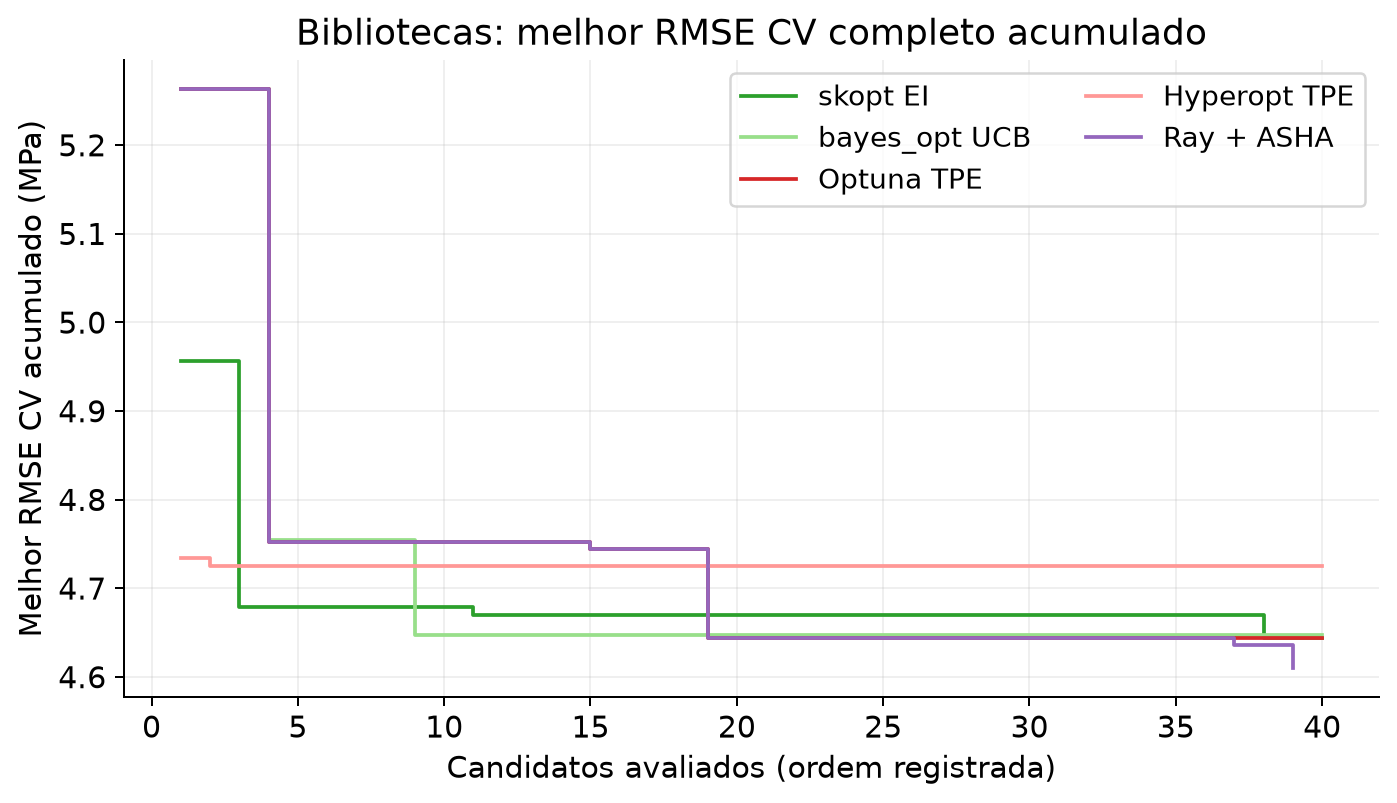

In [33]:
figure('08_bayesian_convergence')

**Item 8.** GA: população 20, 15 gerações, crossover 0,7 e mutação 0,25, genes inteiros. DE: duas estratégias, popsize10×3 dimensões, maxiter15, sem polish; pode terminar antes por tolerância. PSO: 20 partículas, inicialização +15 atualizações, c1=c2=1,5; inércias 0,4/0,7/0,9. As variantes compartilham inicialização; médias PSO são fitness corrente, não pbest.

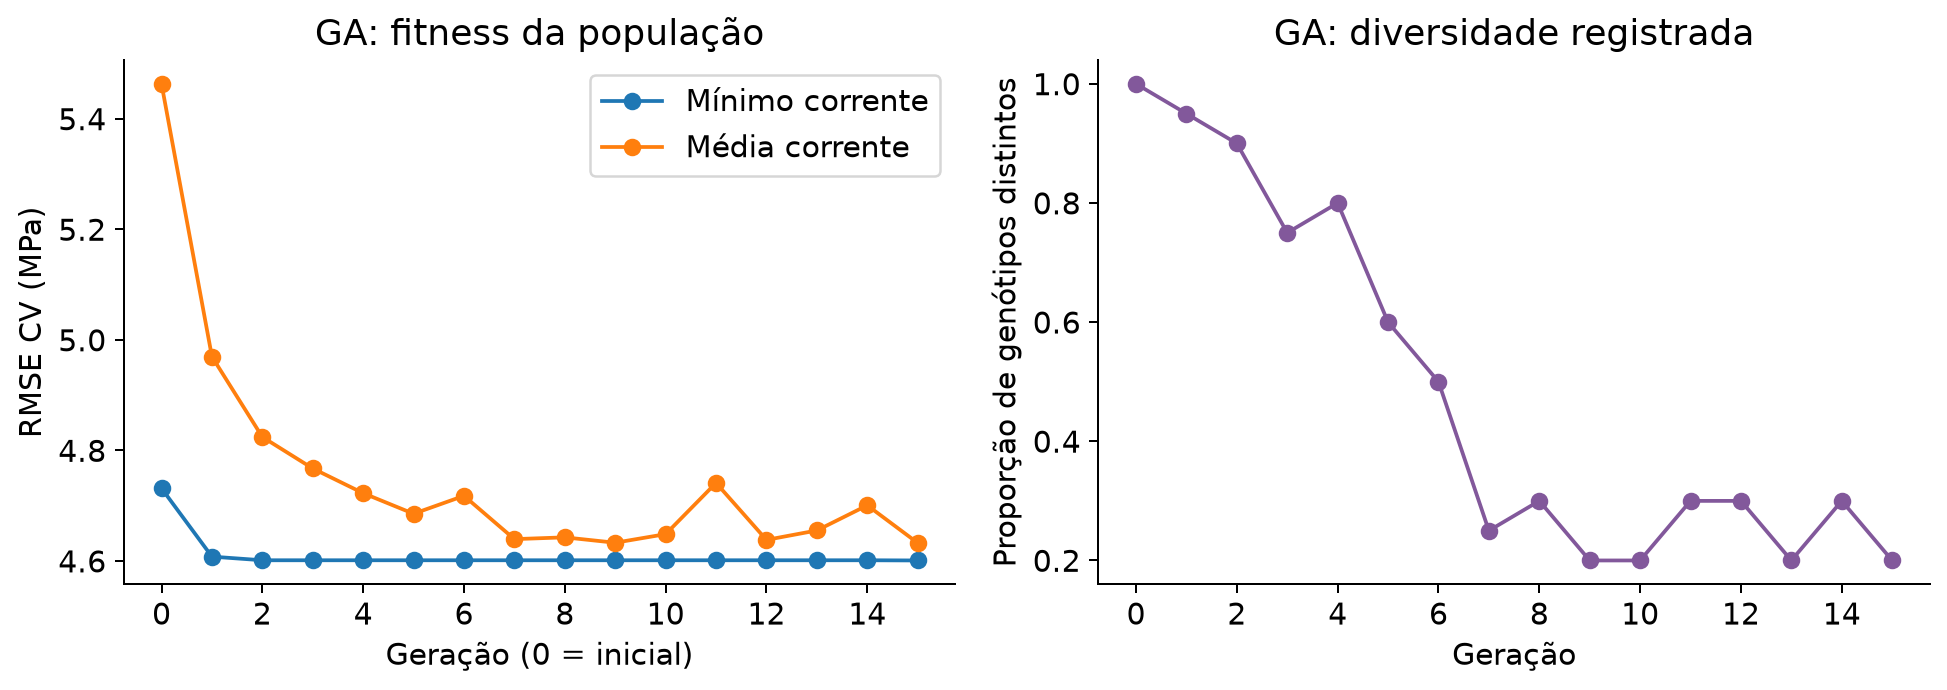

In [34]:
figure('09_ga_generations')

In [35]:
finding('ga')

GA: diversidade registrada de 1.0000 para 0.2000, e melhor fitness corrente de 4.7316 para 4.6010 MPa. O maior intervalo sem nova melhoria acumulada foi de 12 gerações (da 3 à 14); a melhoria na última geração foi de apenas 0.000363 MPa. Contração de diversidade com estagnação sugere risco de convergência prematura, mas não prova um ótimo local nem demonstra distância ao ótimo global desconhecido.

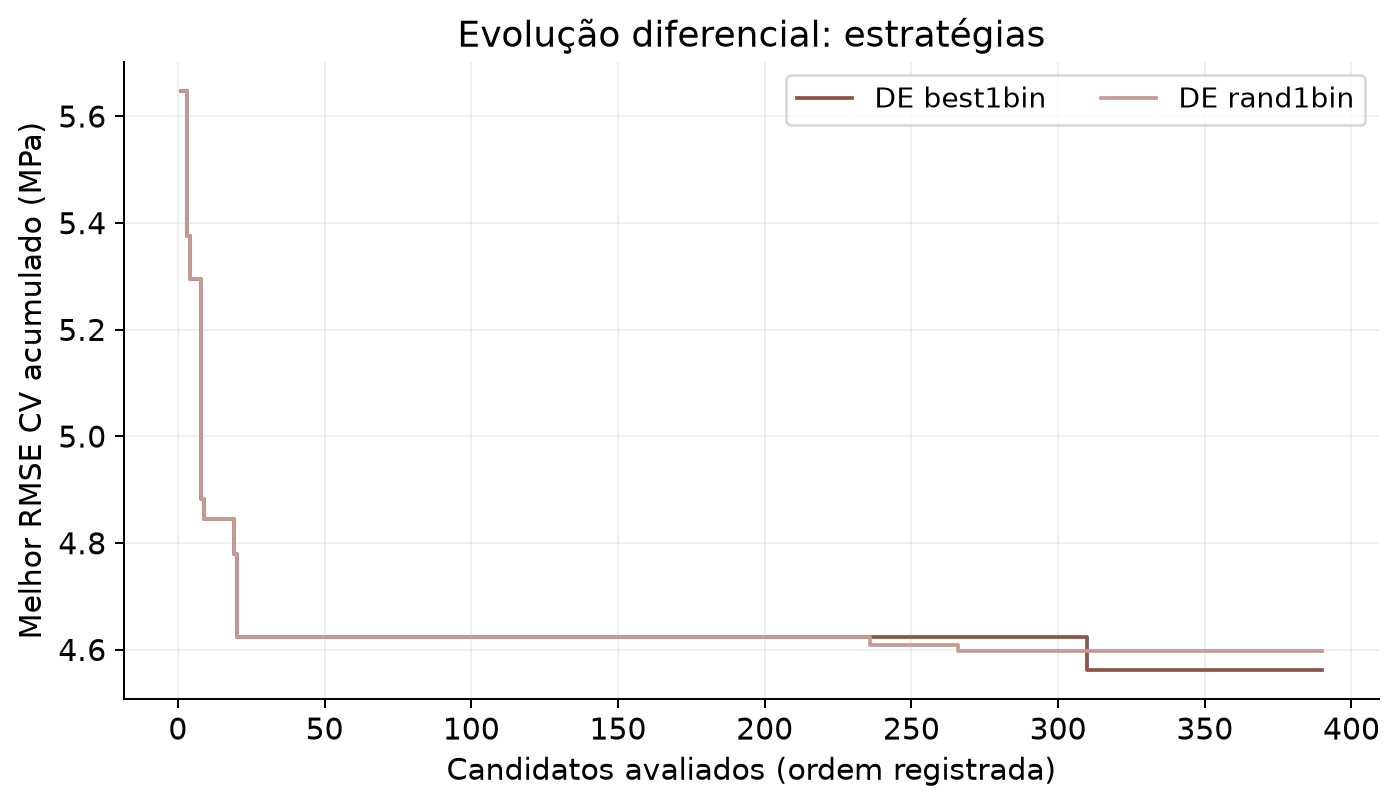

In [36]:
figure('10_de_convergence')

In [37]:
finding('de')

DE best1bin retornou RMSE CV 4.5612 MPa em 390 avaliações; rand1bin, 4.5981 MPa em 390. Tempos totais: 56.677 s e 52.258 s. A curva explicita diferenças de rapidez e patamares; o término segue a tolerância padrão do SciPy ou maxiter = 15. A estratégia best1bin é orientada pelo melhor indivíduo corrente; rand1bin preserva uma base aleatória. Uma execução por estratégia não demonstra superioridade universal.

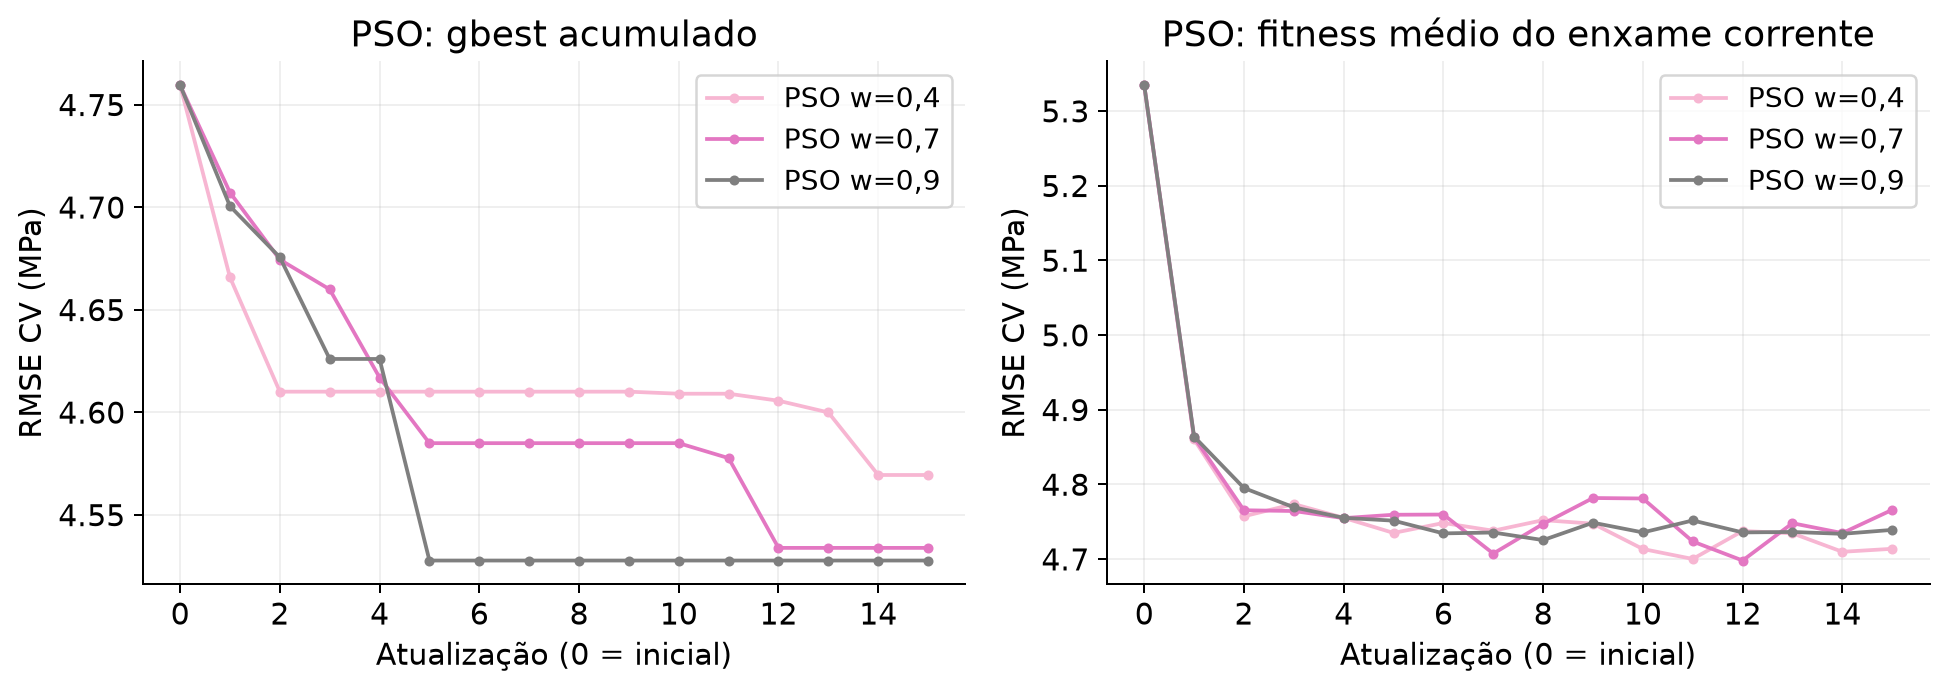

In [38]:
figure('11_pso_inertia')

In [39]:
finding('pso')

Melhor RMSE CV final por inércia: PSO w=0,4=4.5694 MPa, PSO w=0,7=4.5339 MPa, PSO w=0,9=4.5277 MPa. A média é calculada com fitness do enxame corrente. Uma seed por inércia não sustenta recomendação universal sobre w.

### 9. Dashboard comparativo e diagnóstico

Verde: melhor qualidade; amarelo: menor tempo. O radar inclui os 12 métodos principais; as três variantes adicionais ficam na tabela e nos gráficos de sensibilidade. Todos os eixos do radar são normalizados para maior=melhor. A fronteira de Pareto minimiza erro e segundos e preserva empates.

In [40]:
methods()
table_rows(analysis['metrics'],['method','params_json','cv_jobs','n_evaluations','completed_trials','pruned_trials','cv_fits','trained_trees_cv'])

method,cv_rmse,test_rmse,test_mae,test_r2,total_seconds,n_evaluations
baseline,5.29537,5.60385,4.1284,0.894735,0.349276,1
grid,4.73269,4.46302,3.14114,0.933232,4.13446,36
random,4.73269,4.46302,3.14114,0.933232,3.41239,30
gp_manual,4.82543,4.6763,3.43287,0.926698,2.07987,15
bayessearch,4.64356,4.53462,2.98566,0.931073,13.7278,40
bayesopt,4.64757,4.44388,3.08187,0.933804,11.1332,40
optuna,4.64352,4.43283,3.11279,0.934132,6.90624,40
hyperopt,4.72534,4.8299,3.42021,0.921804,5.55121,40
ray,4.60961,4.64281,3.11236,0.927744,160.197,40
ga,4.60103,4.51807,3.01332,0.931575,41.1145,259


method,params_json,cv_jobs,n_evaluations,completed_trials,pruned_trials,cv_fits,trained_trees_cv
baseline,"{""learning_rate"": 0.1, ""n_estimators"": 100, ""subsample"": 1.0}",5,1,1,0,5,500
grid,"{""learning_rate"": 0.2, ""n_estimators"": 150, ""subsample"": 0.8}",5,36,36,0,180,22500
random,"{""learning_rate"": 0.2, ""n_estimators"": 150, ""subsample"": 0.8}",5,30,30,0,150,19250
gp_manual,"{""learning_rate"": 0.2, ""n_estimators"": 100, ""subsample"": 0.8}",5,15,15,0,75,7500
bayessearch,"{""learning_rate"": 0.19903248431364995, ""n_estimators"": 198, ""subsample"": 0.7161110288813025}",5,40,40,0,200,34255
bayesopt,"{""learning_rate"": 0.15067515422521613, ""n_estimators"": 197, ""subsample"": 0.8435483674802927}",5,40,40,0,200,34655
optuna,"{""learning_rate"": 0.18448682291250332, ""n_estimators"": 171, ""subsample"": 0.6973613011542326}",5,40,40,0,200,31310
hyperopt,"{""learning_rate"": 0.15362058128797001, ""n_estimators"": 141, ""subsample"": 0.7201685419162034}",5,40,40,0,200,26275
ray,"{""learning_rate"": 0.19057480414057001, ""n_estimators"": 188, ""subsample"": 0.7016790776038879}",5,40,24,16,585,24935
ga,"{""learning_rate"": 0.19255367900893572, ""n_estimators"": 199, ""subsample"": 0.7124}",5,259,259,0,1295,229515


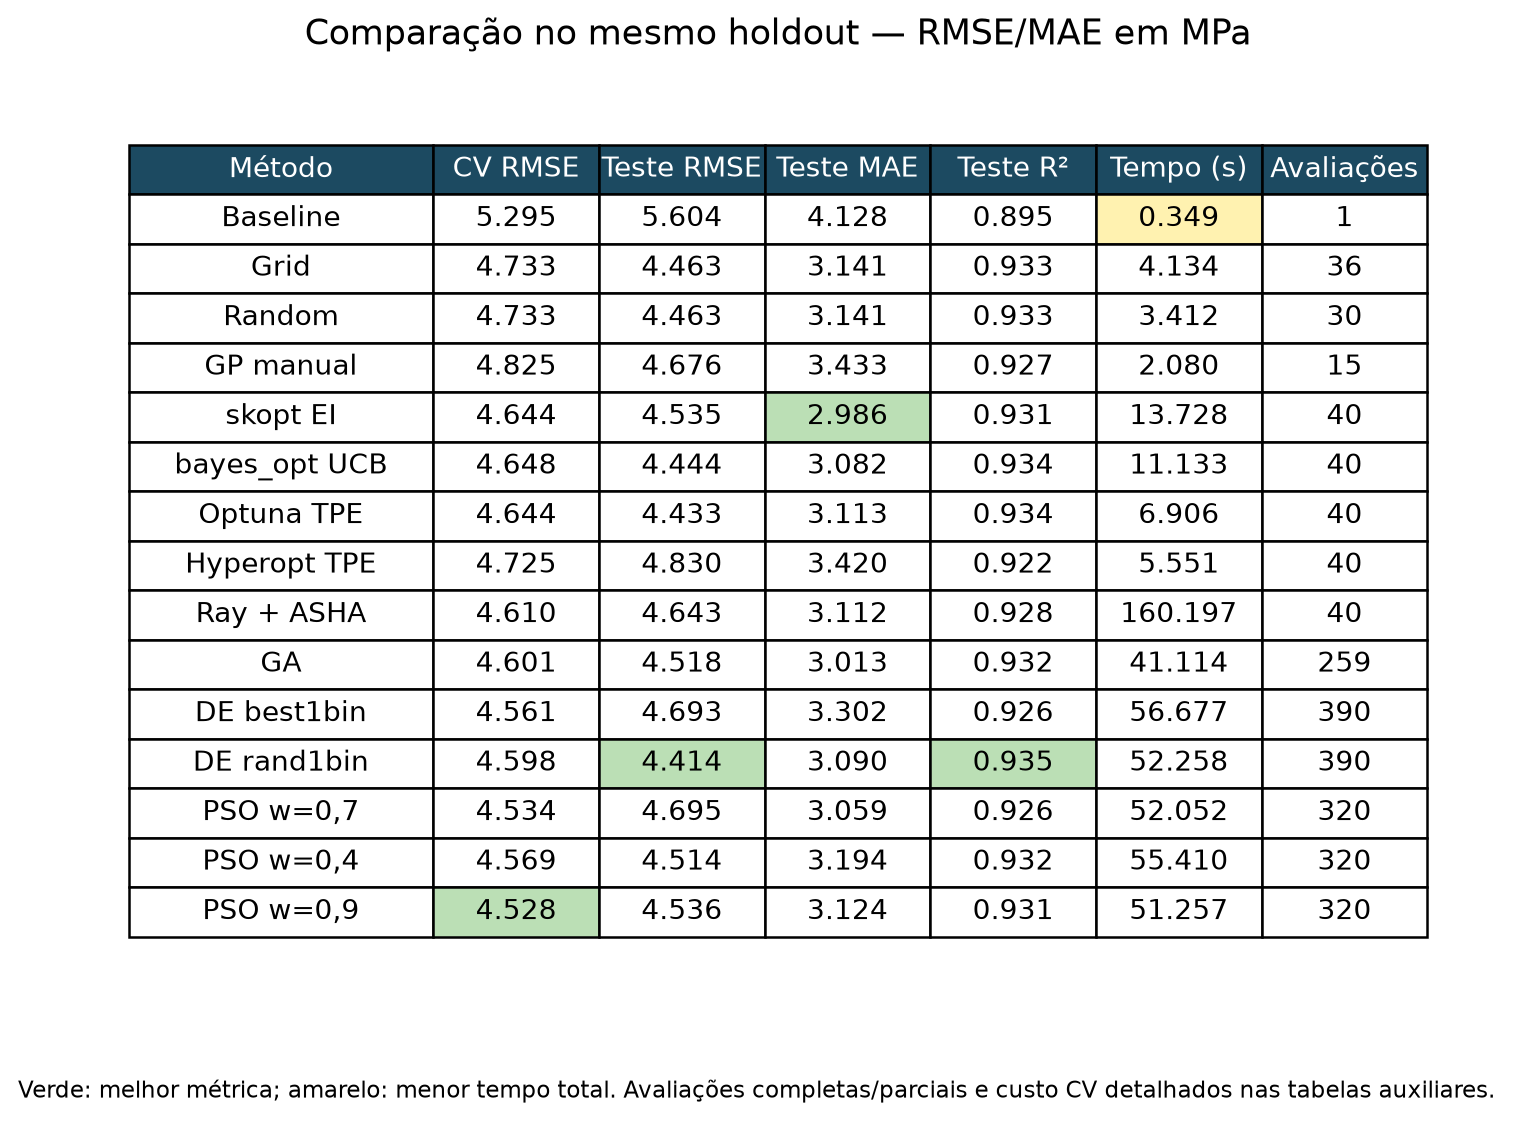

In [41]:
figure('12_comparison_table')

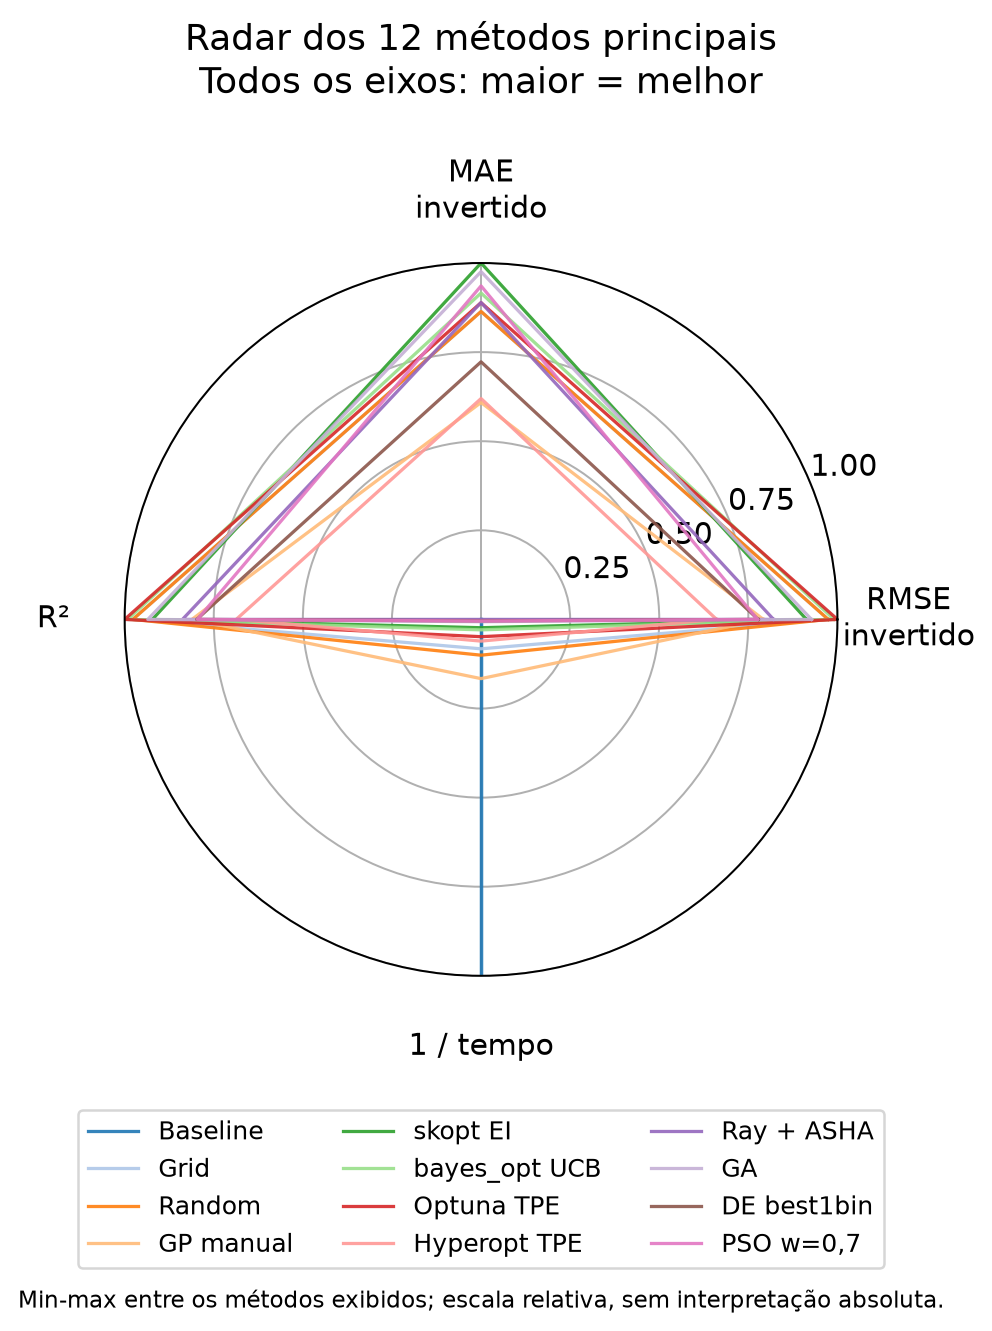

In [42]:
figure('13_radar')

In [43]:
finding('radar')

No conjunto exibido, os líderes de qualidade são Optuna TPE em RMSE, skopt EI em MAE e Optuna TPE em R². O menor tempo total é de Baseline. O radar orienta as quatro escalas para maior=melhor; as normalizações são dependentes dos métodos incluídos, e polígonos próximos não estabelecem equivalência estatística.

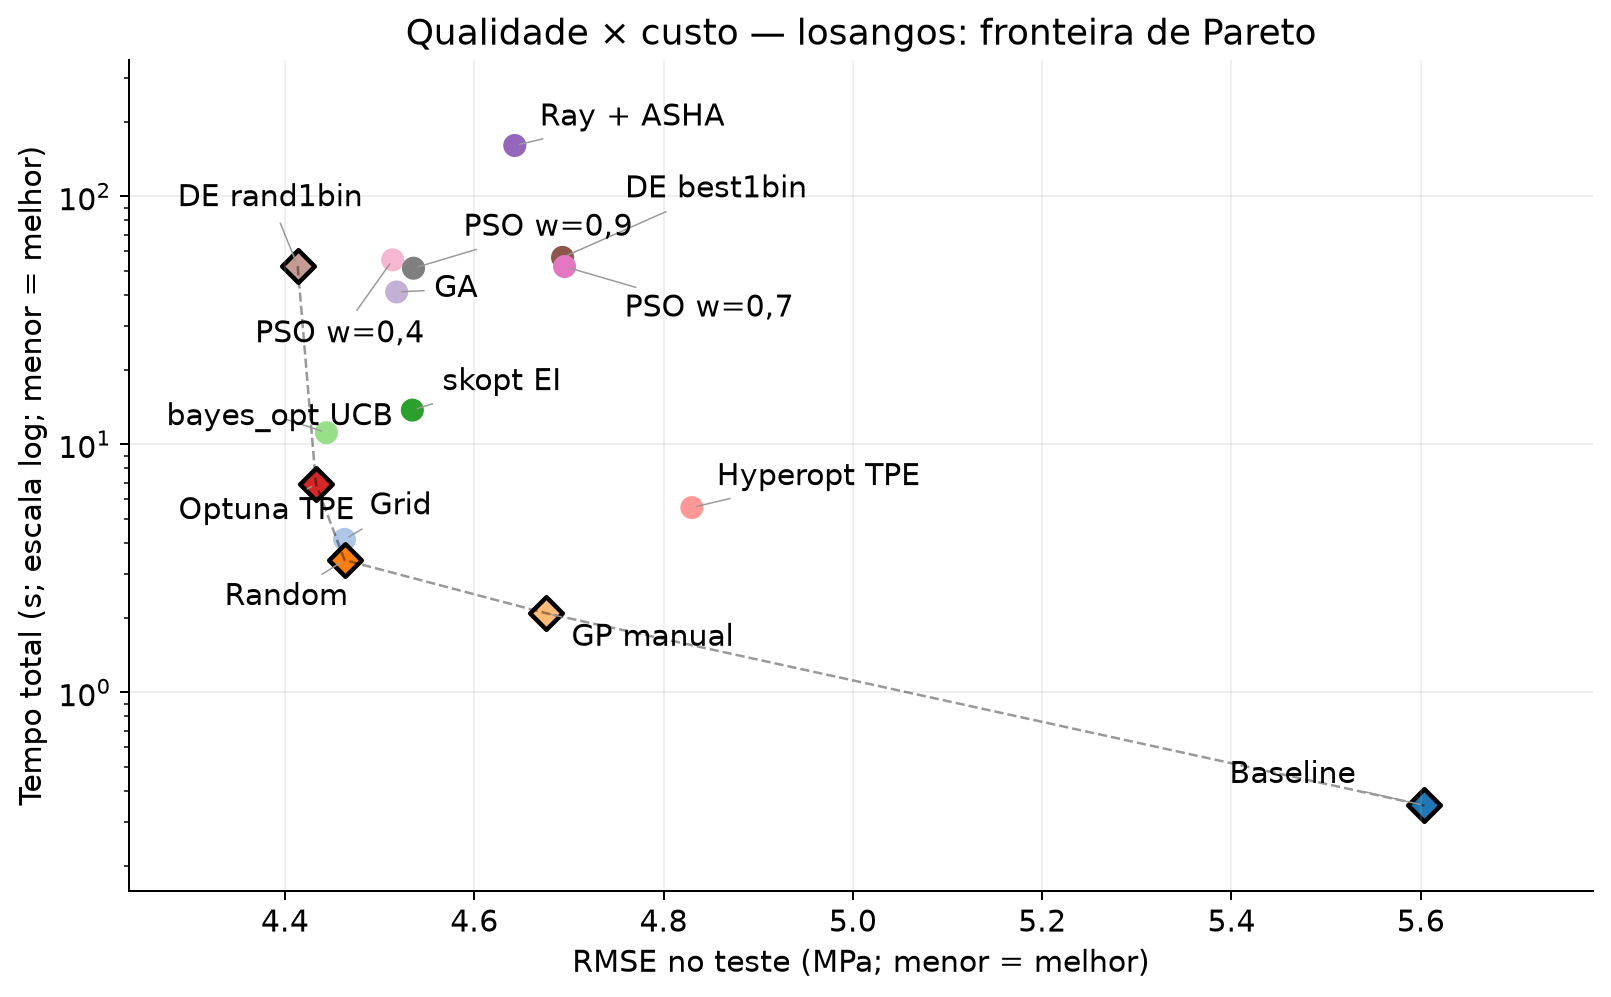

In [44]:
figure('14_pareto')

In [45]:
finding('baseline_gain')

O baseline apresentou RMSE de 5.6039 MPa. O menor RMSE de teste foi 4.4135 MPa (DE rand1bin), redução descritiva de 21.24%. O custo total foi 52.258 s contra 0.349 s; relevância industrial exige uma tolerância externa ao estudo.

In [46]:
finding('scope')

Comparação exploratória em um único holdout do UCI 165. A seleção por teste exigida pela atividade impede interpretar o vencedor como confirmação independente. Nenhum parâmetro foi retunado em função do teste.

In [47]:
finding('spaces')

Grid e Random usam exatamente a mesma grade. Os demais métodos compartilham os limites, porém incluem candidatos contínuos ou quantizados; a comparação mistura estratégia, resolução e budget, portanto não isola o efeito causal do otimizador.

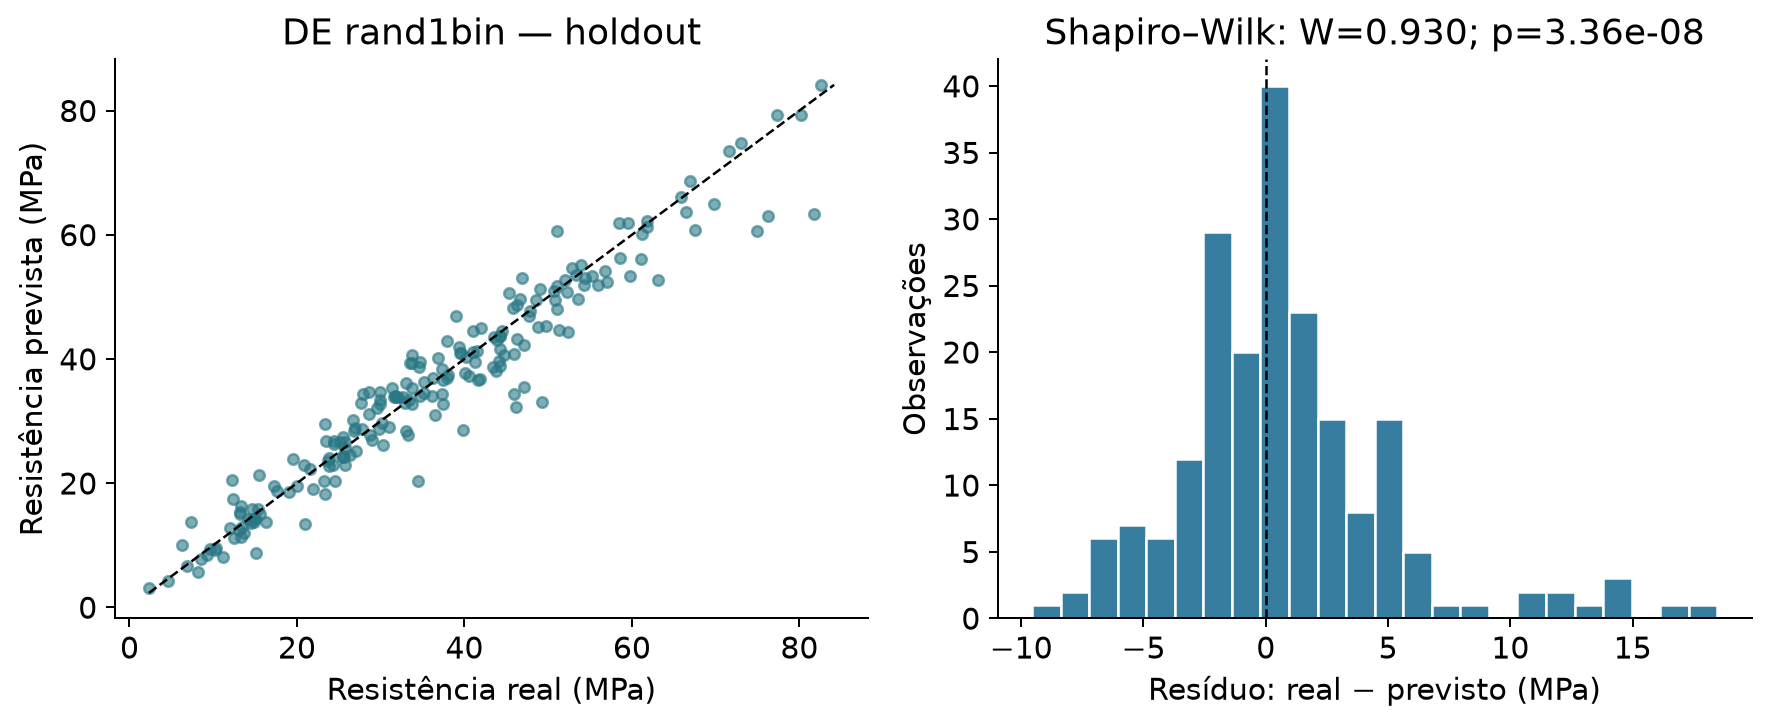

In [48]:
figure('15_best_predictions_residuals')

In [49]:
finding('residuals')

Shapiro–Wilk nos 201 resíduos de teste: W=0.9303, p=3.357e-08. Há evidência contra normalidade a 5%. O diagnóstico é exploratório e normalidade dos resíduos não é requisito para minimizar RMSE com GBR.

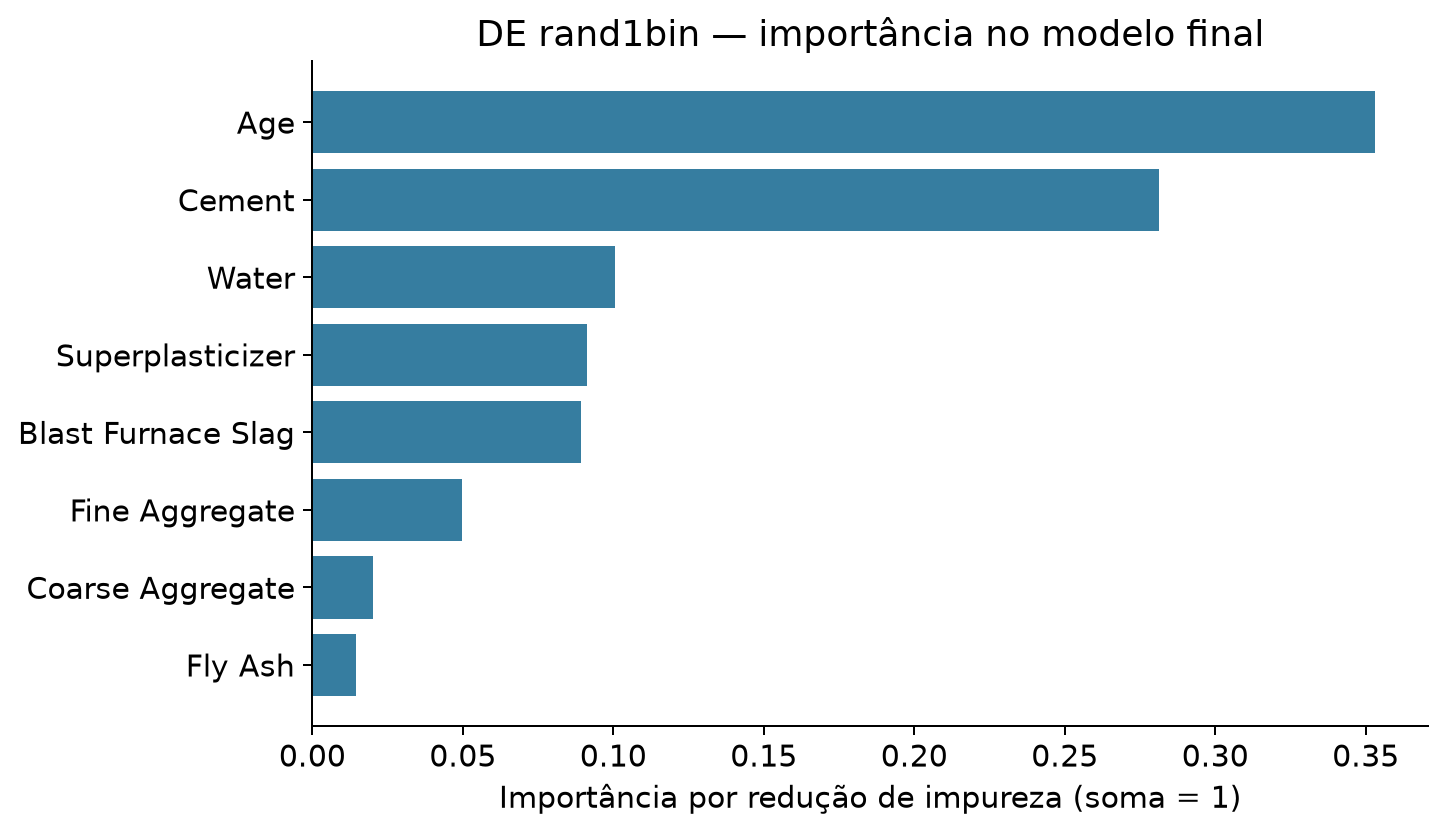

In [50]:
figure('16_feature_importance')

In [51]:
finding('feature_importance')

A importância das features por redução de impureza descreve o modelo ajustado; não mede causalidade. Preditores correlacionados podem redistribuir a importância.

### 10. Importâncias, robustez e custo-benefício

A comparação amostral usa 50% do treino e o mesmo holdout. Robustez repete o HPO inteiro com seeds 0,7,21,42,99 para o vencedor por teste e o por CV, se distintos. As duas séries são resumidas separadamente. Isso mede aleatoriedade computacional condicional ao dataset; não equivale a cinco datasets ou a um IC de generalização.

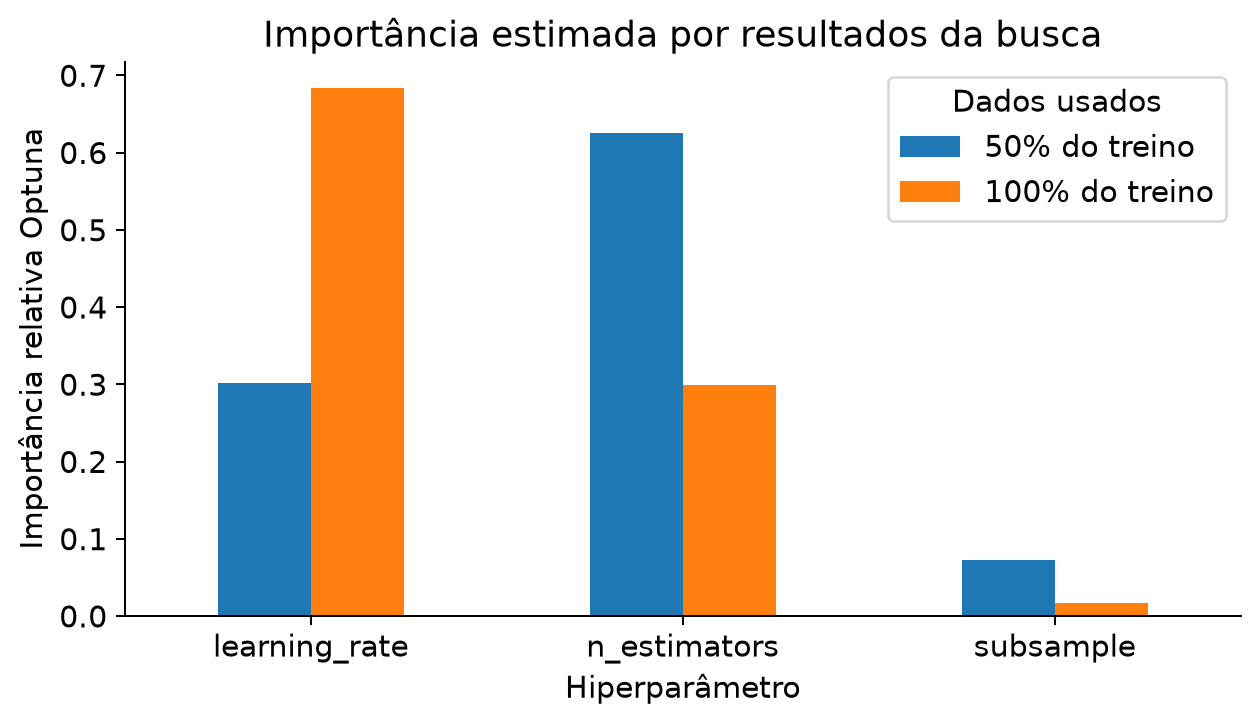

In [52]:
figure('18_optuna_importances')

In [53]:
finding('optuna_importance')

Hiperparâmetro mais importante em cada busca: 50% do treino: n_estimators (importância=0.626); 100% do treino: learning_rate (importância=0.684). O hiperparâmetro líder mudou entre as duas amostras. As importâncias são relativas às 40 avaliações e à distribuição dos candidatos, não uma propriedade universal da feature ou do otimizador. Mudar a amostra também altera o caminho adaptativo da busca; eventuais diferenças não isolam apenas o efeito do tamanho.

In [54]:
csv_table('results/sample-comparison.csv',['method','sample_fraction','train_rows','cv_rmse','test_rmse','total_seconds'])
csv_table('results/robustness.csv')
csv_table('results/robustness-summary.csv')

method,sample_fraction,train_rows,cv_rmse,test_rmse,total_seconds
optuna,1.0,804,4.6435200534576815,4.432828157951514,6.906242499942891
optuna,0.5,402,5.073834776694824,5.677444167457973,4.648314899997786


method,seed,cv_rmse,test_rmse,test_mae,test_r2,search_seconds,refit_seconds,total_seconds,n_evaluations
pso_w09,0,4.554781166212972,4.660333512229623,3.1633328204156625,0.9271977994459594,43.639465800020844,0.13971010001841933,43.77917590003926,320
pso_w09,7,4.566132526211932,4.538826674328498,3.0771830299030625,0.9309445899567863,48.15486280003097,0.1342022999888286,48.2890651000198,320
pso_w09,21,4.595495128827563,4.426286484689527,3.1289229944306243,0.9343265924987035,49.70455749996472,0.1564591999631375,49.86101669992786,320
pso_w09,42,4.527704183493258,4.535849171364094,3.1240622208473483,0.9310351619310688,51.111761900014244,0.14531980000901967,51.257081700023264,320
pso_w09,99,4.56433860851285,4.48263487851194,3.1244091288371356,0.9326438518794855,50.82911349995993,0.15213059994857758,50.98124409990851,320
de_rand1bin,0,4.641292344998723,4.556862339232229,3.162048179782276,0.9303946968542705,40.64446529990528,0.13891880004666746,40.783384099951945,300
de_rand1bin,7,4.653233111580673,4.690940334271325,3.254723882010713,0.9262383998637231,33.45442580000963,0.16508369997609407,33.619509499985725,240
de_rand1bin,21,4.650787158184473,4.578277626907609,3.1867973493229886,0.9297389297455607,32.99673010001425,0.12322720000520349,33.11995730001945,240
de_rand1bin,42,4.598111119646815,4.413513036931648,3.0899071767740756,0.934705088297425,52.1046195999952,0.152959999977611,52.257579599972814,390
de_rand1bin,99,4.652422381340192,4.45550053177514,3.1630840104617866,0.9334568261697058,31.355564999976195,0.17037089995574206,31.525935899931937,240


method,mean,std,min,max,count
de_rand1bin,4.5390187738235905,0.10916363594220892,4.413513036931648,4.690940334271325,5
pso_w09,4.528786144224736,0.08673454928382915,4.426286484689527,4.660333512229623,5


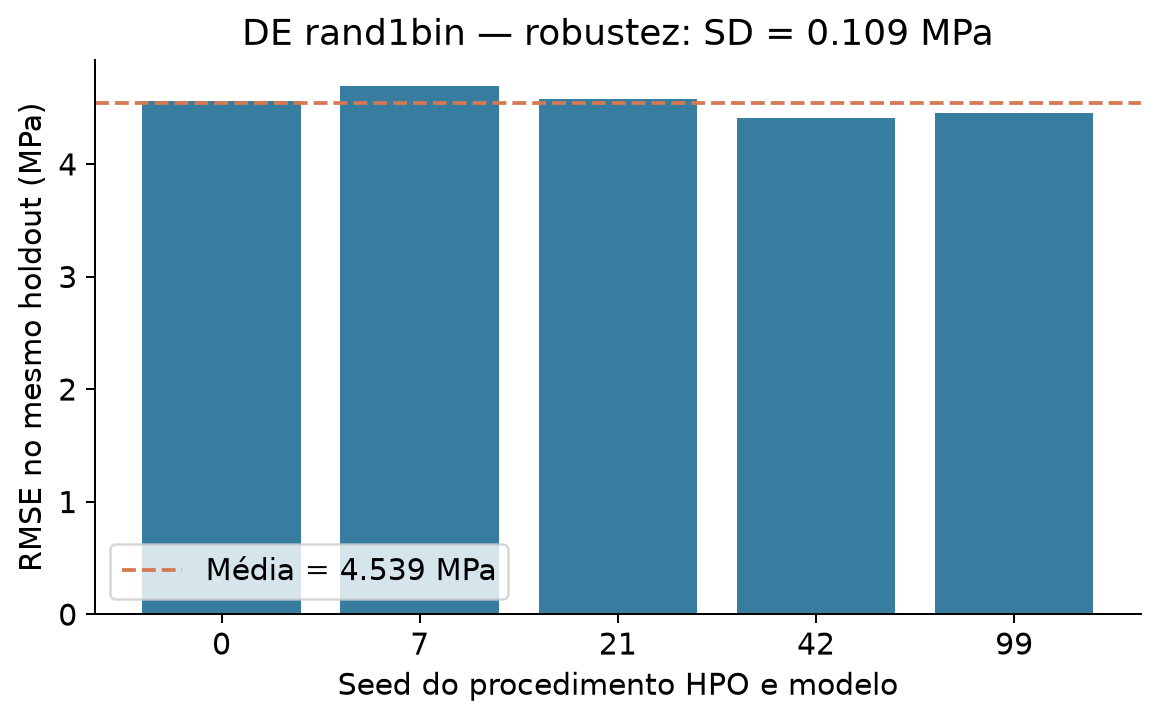

In [55]:
figure('17_robustness')

In [56]:
finding('robustness')

Executar novamente o procedimento HPO completo com cinco seeds, mantendo holdout e folds, resultou em RMSE médio 4.5390 MPa e desvio padrão amostral 0.1092 MPa (mínimo 4.4135, máximo 4.6909). O desvio corresponde a 2.41% da média: a variação é pequena em relação ao nível do erro, mas o desempenho exato depende da seed. Isso descreve estabilidade computacional no dataset fixo; sem tolerância industrial definida e validação externa, não estabelece estabilidade operacional ou populacional.

In [57]:
finding('uncertainty')

Os cinco folds orientam a seleção e não são cinco datasets independentes. As cinco seeds medem sensibilidade computacional no mesmo holdout, não incerteza completa de generalização. Não se conclui superioridade estatística universal.

Eficiência = melhoria relativa do RMSE sobre baseline / tempo adicional. Baseline e denominadores não positivos são indefinidos, sem divisão por zero nem epsilon.

In [58]:
table_rows(analysis['efficiency'])

method,relative_rmse_improvement,additional_seconds,efficiency_per_second,status
baseline,0,0,None,undefined_nonpositive_delta_time
grid,0.203579,3.78519,0.053783,defined
random,0.203579,3.06312,0.0664614,defined
gp_manual,0.16552,1.73059,0.0956433,defined
bayessearch,0.190803,13.3785,0.0142618,defined
bayesopt,0.206995,10.7839,0.0191949,defined
optuna,0.208967,6.55697,0.0318695,defined
hyperopt,0.138111,5.20194,0.0265499,defined
ray,0.171497,159.848,0.00107288,defined
ga,0.193756,40.7652,0.00475298,defined


In [59]:
if MODO=='analise_arquivada':
    finding('recommendation')
else:
    display(Markdown('**Interpretação desta nova execução:** campeão CV = '+analysis['method_labels'][analysis['best_cv_method']]+
        '; vencedor descritivo no teste = '+analysis['method_labels'][analysis['best_test_method']]+
        '. Compare qualidade, tempo e facilidade de integração antes de escolher o método operacional. '
        'A recomendação Optuna do relatório original é uma análise daquele resultado e não é automaticamente transferida para este novo runtime.'))


Adotaria Optuna TPE como candidato operacional provisório pelo compromisso entre CV, custo e integração: CV RMSE 4.6435 MPa em 6.906 s, com 40 trials e o mesmo pipeline. A seleção formal pelo menor CV continua sendo PSO w=0,9 (4.5277 MPa; 51.257 s). Random Search é a alternativa mais simples para orçamento menor. Fixaria versões, seeds, split e budget e validaria em novos lotes antes de produção. Essa recomendação é uma interpretação pós-resultados; as métricas de teste são descritivas, e não o critério principal da escolha operacional.

## Código integral, proveniência e exportação

O engine e a análise abaixo são exatamente os fontes baixados do commit registrado. Nenhum arquivo Windows é necessário; os caminhos são criados no runtime. O SHA dos fontes, versões instaladas, comandos, limites e logs acompanham a execução. Tempos novos com menos CPUs não devem ser comparados diretamente ao benchmark original com cinco workers.

In [60]:
for name in ['experiment.py','plot_results.py']:
    display(HTML('<details><summary>'+html.escape(name)+' — código completo</summary><pre>'+html.escape((RUN_DIR/name).read_text(encoding='utf-8'))+'</pre></details>'))
display(HTML('<pre>'+html.escape(json.dumps(MANIFEST,ensure_ascii=False,indent=2))+'</pre>'))

In [61]:
archive_path=Path(shutil.make_archive(str(BASE/('Aula05-'+RUN_ID)), 'zip', RUN_DIR))
print('Pacote com resultados, dados, fontes, figuras, manifesto e logs:',archive_path)
try:
    from google.colab import files
    files.download(str(archive_path))
except ImportError:
    display(FileLink(str(archive_path)))


Pacote com resultados, dados, fontes, figuras, manifesto e logs: /root/codex-aula05-validation/work/aula05_colab/Aula05-20261001T002128Z-d889e05b.zip


/root/codex-aula05-validation/work/aula05_colab/Aula05-20261001T002128Z-d889e05b.zip

Referências de infraestrutura: [FAQ oficial do Colab](https://research.google.com/colaboratory/faq.html), [runtime e Python do Colab](https://github.com/googlecolab/backend-info), [ambientes venv](https://docs.python.org/3/library/venv.html), [instalação do Ray Tune](https://docs.ray.io/en/latest/ray-overview/installation.html), [Python isolado via uv](https://docs.astral.sh/uv/guides/install-python/). Fonte do dataset: [UCI 165](https://archive.ics.uci.edu/dataset/165/concrete+compressive+strength). Framework: [rnd-superpowers no commit solicitado](https://github.com/juniortlr/rnd-superpowers/commit/f68892c8b7adba358b8aa437eec00a89fe88d340).